## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Extract Dataset

In [2]:
# Extract the rice image dataset from Google Drive
import zipfile

zip_path = "/content/drive/MyDrive/Rice_Image_Dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/rice_data")

# Import Libraries

In [3]:
# Import the required libraries
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers, models

## Explore Dataset Directory

In [4]:
# Check dataset path and explore directory contents
dataset_directory = "/content/rice_data/Rice_Image_Dataset"

print(os.listdir(dataset_directory))

['Karacadag', 'Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'S0168169921003021.pdf', 'Rice_Citation_Request.txt']


## Check Class Distribution

In [5]:
# Check the number of images in each rice class
import os

base_path = "/content/rice_data/Rice_Image_Dataset"

for class_name in ["Arborio", "Basmati", "Ipsala", "Jasmine", "Karacadag"]:
    count = len(os.listdir(os.path.join(base_path, class_name)))
    print(class_name, count)

Arborio 15000
Basmati 15000
Ipsala 15000
Jasmine 15000
Karacadag 15000


# Data Preprocessing

In [6]:
# Filter and keep only valid rice folder names in a fixed order
rice_classes = []

for item in sorted(os.listdir(dataset_directory)):
    item_path = os.path.join(dataset_directory, item)

    if os.path.isdir(item_path):
        rice_classes.append(item)

print(rice_classes)

['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


In [7]:
# Count number of images in each rice class folder
for rice_name in rice_classes:
    folder_path = os.path.join(dataset_directory, rice_name)
    image_list = os.listdir(folder_path)
    print(f"{rice_name}: {len(image_list)} images")

Arborio: 15000 images
Basmati: 15000 images
Ipsala: 15000 images
Jasmine: 15000 images
Karacadag: 15000 images


In [8]:
# Print the first 3 file names from each rice class
for rice_name in rice_classes:
    folder_path = os.path.join(dataset_directory, rice_name)
    sample_files = sorted(os.listdir(folder_path))[:3]
    print(f"{rice_name}: {sample_files}")

Arborio: ['Arborio (1).jpg', 'Arborio (10).jpg', 'Arborio (100).jpg']
Basmati: ['Basmati (1).jpg', 'basmati (10).jpg', 'basmati (100).jpg']
Ipsala: ['Ipsala (1).jpg', 'Ipsala (10).jpg', 'Ipsala (100).jpg']
Jasmine: ['Jasmine (1).jpg', 'Jasmine (10).jpg', 'Jasmine (100).jpg']
Karacadag: ['Karacadag (1).jpg', 'Karacadag (10).jpg', 'Karacadag (100).jpg']


In [9]:
# Check the format, size, and color mode of one image from each class
from PIL import Image

for rice_name in rice_classes:
    class_folder_path = os.path.join(dataset_directory, rice_name)
    first_file_name = sorted(os.listdir(class_folder_path))[0]
    full_image_path = os.path.join(class_folder_path, first_file_name)

    with Image.open(full_image_path) as img:
        print(
            f"Class: {rice_name:10} | Format: {img.format} | "
            f"Size: {img.size} | Mode: {img.mode}"
        )

Class: Arborio    | Format: JPEG | Size: (250, 250) | Mode: RGB
Class: Basmati    | Format: JPEG | Size: (250, 250) | Mode: RGB
Class: Ipsala     | Format: JPEG | Size: (250, 250) | Mode: RGB
Class: Jasmine    | Format: JPEG | Size: (250, 250) | Mode: RGB
Class: Karacadag  | Format: JPEG | Size: (250, 250) | Mode: RGB


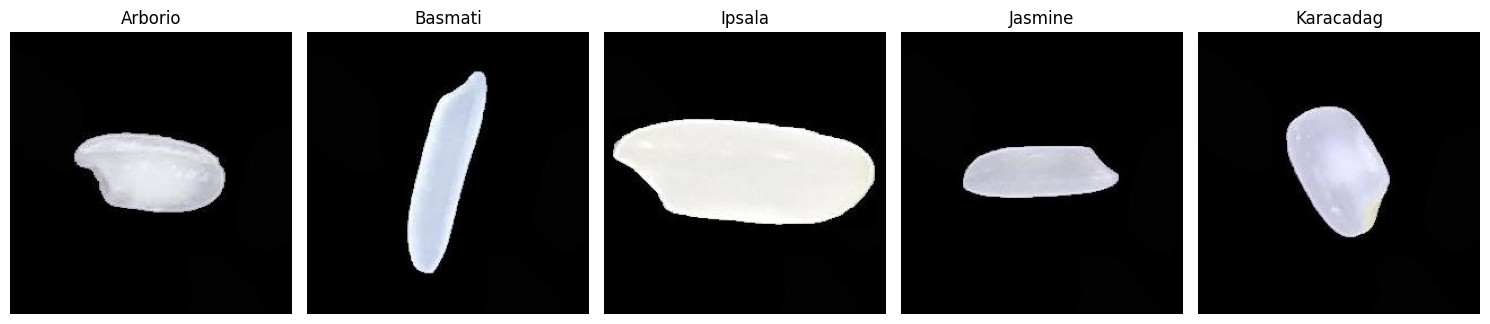

In [10]:
# Display one sample image from each rice class
plt.figure(figsize=(15, 5))

for index, rice_name in enumerate(rice_classes):
    class_folder_path = os.path.join(dataset_directory, rice_name)
    first_image_file = sorted(os.listdir(class_folder_path))[0]
    full_image_path = os.path.join(class_folder_path, first_image_file)

    image = Image.open(full_image_path)

    plt.subplot(1, 5, index + 1)
    plt.imshow(image)
    plt.title(rice_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
# Create a reproducible list containing the full path of every image
image_paths = []

for rice_name in rice_classes:
    class_folder_path = os.path.join(dataset_directory, rice_name)

    for image_name in sorted(os.listdir(class_folder_path)):
        image_paths.append(os.path.join(class_folder_path, image_name))

print("Total images:", len(image_paths))

Total images: 75000


In [12]:
# Shuffle the image paths reproducibly and split them into training, validation, and test sets
import random

random.seed(123)
random.shuffle(image_paths)

train_end = int(0.8 * len(image_paths))
val_end = int(0.9 * len(image_paths))

train_paths = image_paths[:train_end]
val_paths = image_paths[train_end:val_end]
test_paths = image_paths[val_end:]

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 60000
Validation: 7500
Test: 7500


In [13]:
# Load and preprocess each image and extract its class label
def load_data(path):
    image = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    image = tf.cast(image, tf.float32) / 255.0

    class_name = tf.strings.split(path, os.sep)[-2]
    label = tf.argmax(
        tf.cast(tf.equal(rice_classes, class_name), tf.int32)
    )

    return image, label

In [14]:
# Create efficient TensorFlow datasets for training, validation, and testing
train_dataset = (
    tf.data.Dataset.from_tensor_slices(train_paths)
    .map(load_data, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(buffer_size=1000, seed=123, reshuffle_each_iteration=True)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices(val_paths)
    .map(load_data, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices(test_paths)
    .map(load_data, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

In [15]:
# Check the shape of one batch
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 250, 250, 3)
Labels shape: (32,)


## Create CNN Model

In [ ]:
# Clear the previous Keras session before building a new model
tf.keras.backend.clear_session()

In [ ]:
# Build the baseline CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(250, 250, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
], name='Rice_CNN')

In [ ]:
# Display the architecture and parameters of the baseline CNN model
model.summary()

Model: "Rice_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 248, 248, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 124, 124, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 238144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    30,482,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,502,597 (116.36 MB)

 Trainable params: 30,502,597 (116.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the baseline CNN model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
# Save the model after every training epoch
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/Baseline_Epoch_{epoch:02d}.keras',
    save_freq='epoch',
    save_best_only=False,
    verbose=1
)

In [ ]:
# Train the baseline CNN and save every epoch
training_history_1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[checkpoint]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9269 - loss: 0.2320
Epoch 1: saving model to /content/drive/MyDrive/Baseline_Epoch_01.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Baseline_Epoch_01.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 119s 60ms/step - accuracy: 0.9595 - loss: 0.1244 - val_accuracy: 0.9695 - val_loss: 0.0885
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9792 - loss: 0.0643
Epoch 2: saving model to /content/drive/MyDrive/Baseline_Epoch_02.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Baseline_Epoch_02.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 122s 65ms/step - accuracy: 0.9811 - loss: 0.0570 - val_accuracy: 0.9832 - val_loss: 0.0488
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9873 - loss: 0.0362
Epoch 3: saving model to /content/drive/MyDrive/Baseline_Epoch_03.keras

Epoch 3: finished saving model to /content/drive/MyDrive/Baseline_Epoch_03.keras
1875/1875 ━━━━━━━━━━━━━━━━━

In [ ]:
# Load the saved training history and find the best epoch
import json

with open('/content/drive/MyDrive/Baseline_Training_History_Final.json', 'r') as file:
    baseline_history = json.load(file)

best_baseline_epoch = np.argmax(baseline_history['val_accuracy']) + 1
best_baseline_val_accuracy = max(baseline_history['val_accuracy'])

print("Best Epoch:", best_baseline_epoch)
print(f"Best Validation Accuracy: {best_baseline_val_accuracy * 100:.2f}%")

Best Epoch: 10
Best Validation Accuracy: 98.88%


In [ ]:
# Load the saved model from the final epoch
baseline_epoch10 = tf.keras.models.load_model(
    '/content/drive/MyDrive/Baseline_Epoch_10.keras'
)

In [ ]:
# Evaluate the loaded Epoch 10 model on the test dataset
test_loss, test_accuracy = baseline_epoch10.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy (%): {test_accuracy * 100:.2f}%")

235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9857 - loss: 0.0761
Test Loss: 0.0761
Test Accuracy: 0.9857
Test Accuracy (%): 98.57%


In [ ]:
# Save the new baseline training history to Google Drive
import json

history_path = '/content/drive/MyDrive/Baseline_Training_History_Final.json'

with open(history_path, 'w') as file:
    json.dump(training_history_1.history, file, indent=4)

print("Training history saved successfully.")

Training history saved successfully.


In [ ]:
# Generate predictions using the final baseline model
y_true = np.concatenate([
    labels.numpy() for images, labels in test_dataset
])

y_pred = np.argmax(
    baseline_epoch10.predict(test_dataset),
    axis=1
)

235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step


In [ ]:
# Count correct and incorrect predictions for the final baseline model
correct_predictions = np.sum(y_true == y_pred)
incorrect_predictions = np.sum(y_true != y_pred)

print("Correct predictions:", correct_predictions)
print("Incorrect predictions:", incorrect_predictions)
print("Total test images:", len(y_true))

Correct predictions: 7393
Incorrect predictions: 107
Total test images: 7500


In [ ]:
# Generate the classification report for the final baseline model
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=rice_classes,
    digits=4
))

              precision    recall  f1-score   support

     Arborio     0.9697    0.9875    0.9786      1525
     Basmati     0.9885    0.9858    0.9871      1476
      Ipsala     1.0000    0.9929    0.9964      1542
     Jasmine     0.9812    0.9853    0.9833      1431
   Karacadag     0.9894    0.9771    0.9832      1526

    accuracy                         0.9857      7500
   macro avg     0.9858    0.9857    0.9857      7500
weighted avg     0.9858    0.9857    0.9858      7500



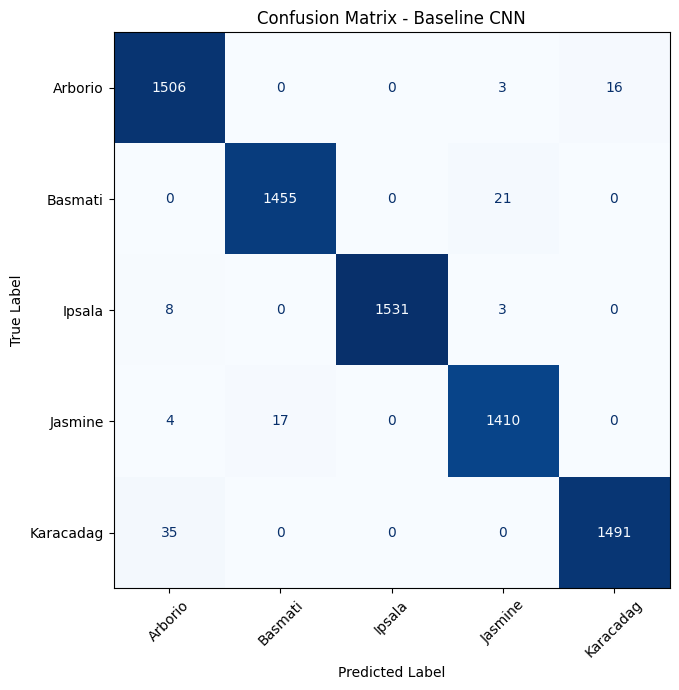

In [ ]:
# Plot the confusion matrix for the final baseline model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rice_classes
)

disp.plot(
    ax=ax,
    cmap='Blues',
    values_format='d',
    colorbar=False
)

plt.title('Confusion Matrix - Baseline CNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Save the final baseline evaluation results to Google Drive
baseline_results = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "correct_predictions": int(correct_predictions),
    "incorrect_predictions": int(incorrect_predictions),
    "total_test_images": int(len(y_true)),
    "confusion_matrix": cm.tolist()
}

with open('/content/drive/MyDrive/Baseline_Results_Final.json', 'w') as file:
    json.dump(baseline_results, file, indent=4)

print("Final baseline results saved successfully.")

Final baseline results saved successfully.


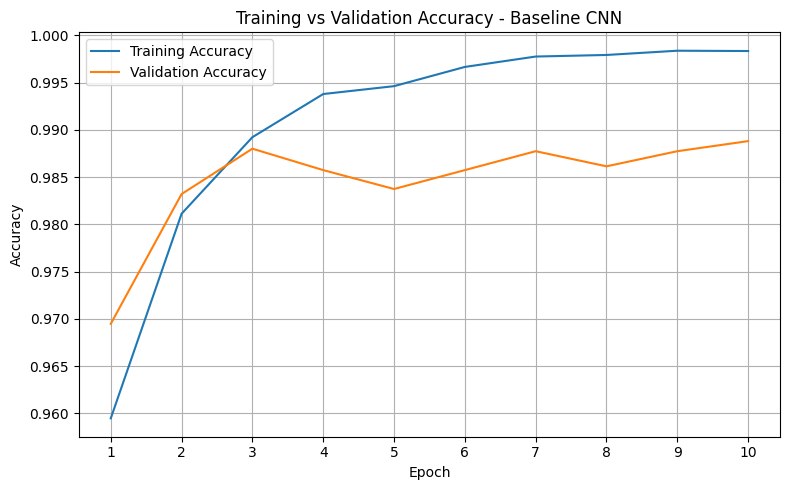

In [ ]:
# Plot training and validation accuracy
epochs = range(1, len(training_history_1.history['accuracy']) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, training_history_1.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, training_history_1.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy - Baseline CNN')
plt.xticks(epochs)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

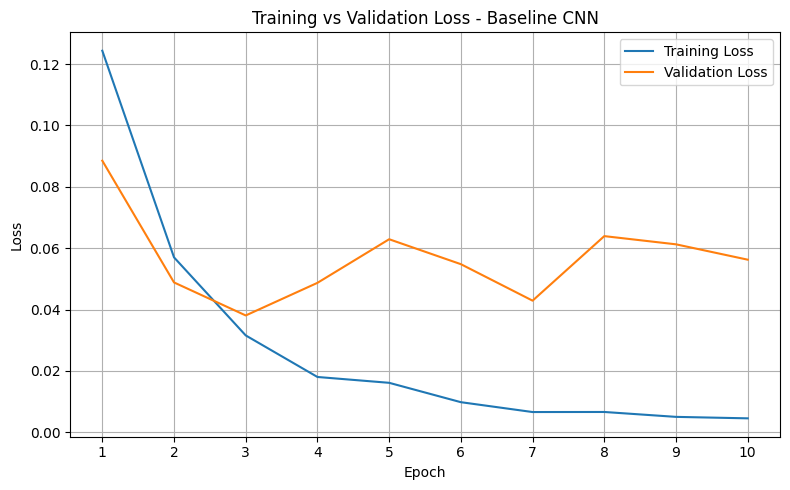

In [ ]:
# Plot training and validation loss
epochs = range(1, len(training_history_1.history['loss']) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, training_history_1.history['loss'], label='Training Loss')
plt.plot(epochs, training_history_1.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss - Baseline CNN')
plt.xticks(epochs)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Baseline CNN Results

Baseline CNN Results

The baseline CNN achieved 98.57% test accuracy with a test loss of 0.0761.

Out of 7,500 test images, 7,393 images were classified correctly and 107 images were misclassified.

The model showed strong performance across all five rice classes. Ipsala achieved the highest F1-score, while Arborio obtained the lowest F1-score among the five classes.

According to the confusion matrix, the most frequent classification errors occurred between Karacadag and Arborio, and between Basmati and Jasmine.

The training and validation curves indicate some signs of overfitting in the later epochs, where the training loss continued to decrease while the validation loss showed fluctuations.

This baseline model provides a reference point for comparing the performance, efficiency, and improvements of the following CNN models.

## Improved CNN Model

To improve the baseline model, a deeper CNN architecture is introduced by adding an extra convolutional layer, Global Average Pooling, and Dropout. The aim is to improve feature extraction and model generalization while significantly reducing the number of trainable parameters compared with the baseline CNN.

In [ ]:
# Clear the previous Keras session before building a new model
tf.keras.backend.clear_session()

In [ ]:
# Build the improved CNN model
model_improved = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(250, 250, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(5, activation='softmax')
], name='Improved_Rice_CNN')

model_improved.summary()

Model: "Improved_Rice_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 248, 248, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 124, 124, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 59, 59, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the improved CNN model
model_improved.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
# Save the improved model after every training epoch
improved_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/Improved_Epoch_{epoch:02d}.keras',
    save_freq='epoch',
    save_best_only=False,
    verbose=1
)

In [ ]:
# Train the improved CNN and save every epoch
training_history_improved = model_improved.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[improved_checkpoint]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6432 - loss: 0.8244
Epoch 1: saving model to /content/drive/MyDrive/Improved_Epoch_01.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Improved_Epoch_01.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 145s 71ms/step - accuracy: 0.7889 - loss: 0.5307 - val_accuracy: 0.9280 - val_loss: 0.1922
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8916 - loss: 0.2983
Epoch 2: saving model to /content/drive/MyDrive/Improved_Epoch_02.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Improved_Epoch_02.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 129s 68ms/step - accuracy: 0.8963 - loss: 0.2857 - val_accuracy: 0.9267 - val_loss: 0.2245
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9103 - loss: 0.2525
Epoch 3: saving model to /content/drive/MyDrive/Improved_Epoch_03.keras

Epoch 3: finished saving model to /content/drive/MyDrive/Improved_Epoch_03.keras
1875/1875 ━━━━━━━━━━━━━━━━━

In [ ]:
# Load the saved training history and find the best epoch
import json

with open('/content/drive/MyDrive/Improved_Training_History_Final.json', 'r') as file:
    improved_history = json.load(file)

best_improved_epoch = np.argmax(improved_history['val_accuracy']) + 1
best_improved_val_accuracy = max(improved_history['val_accuracy'])

print("Best Epoch:", best_improved_epoch)
print(f"Best Validation Accuracy: {best_improved_val_accuracy * 100:.2f}%")

Best Epoch: 8
Best Validation Accuracy: 99.49%


In [ ]:
# Find the epoch with the highest validation accuracy
best_improved_epoch = np.argmax(training_history_improved.history['val_accuracy']) + 1
best_improved_val_accuracy = max(training_history_improved.history['val_accuracy'])

print("Best Epoch:", best_improved_epoch)
print(f"Best Validation Accuracy: {best_improved_val_accuracy * 100:.2f}%")

Best Epoch: 8
Best Validation Accuracy: 99.49%


In [ ]:
# Load the saved model from the best epoch
improved_epoch8 = tf.keras.models.load_model(
    '/content/drive/MyDrive/Improved_Epoch_08.keras'
)

In [ ]:
# Evaluate the loaded Epoch 8 model on the test dataset
improved_test_loss, improved_test_accuracy = improved_epoch8.evaluate(test_dataset)

print(f"Test Loss: {improved_test_loss:.4f}")
print(f"Test Accuracy: {improved_test_accuracy:.4f}")
print(f"Test Accuracy (%): {improved_test_accuracy * 100:.2f}%")

235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9919 - loss: 0.0263
Test Loss: 0.0263
Test Accuracy: 0.9919
Test Accuracy (%): 99.19%


In [ ]:
# Save the improved CNN training history to Google Drive
import json

improved_history_path = '/content/drive/MyDrive/Improved_Training_History_Final.json'

with open(improved_history_path, 'w') as file:
    json.dump(training_history_improved.history, file, indent=4)

print("Improved training history saved successfully.")

Improved training history saved successfully.


In [ ]:
# Generate predictions using the best improved model
improved_y_true = np.concatenate([
    labels.numpy() for images, labels in test_dataset
])

improved_y_pred = np.argmax(
    improved_epoch8.predict(test_dataset),
    axis=1
)

235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step


In [ ]:
# Count correct and incorrect predictions for the best improved model
improved_correct_predictions = np.sum(improved_y_true == improved_y_pred)
improved_incorrect_predictions = np.sum(improved_y_true != improved_y_pred)

print("Correct predictions:", improved_correct_predictions)
print("Incorrect predictions:", improved_incorrect_predictions)
print("Total test images:", len(improved_y_true))

Correct predictions: 7439
Incorrect predictions: 61
Total test images: 7500


In [ ]:
# Generate the classification report for the best improved model
from sklearn.metrics import classification_report

print(classification_report(
    improved_y_true,
    improved_y_pred,
    target_names=rice_classes,
    digits=4
))

              precision    recall  f1-score   support

     Arborio     0.9850    0.9928    0.9889      1525
     Basmati     0.9986    0.9858    0.9922      1476
      Ipsala     1.0000    0.9961    0.9981      1542
     Jasmine     0.9827    0.9923    0.9875      1431
   Karacadag     0.9928    0.9921    0.9925      1526

    accuracy                         0.9919      7500
   macro avg     0.9918    0.9918    0.9918      7500
weighted avg     0.9919    0.9919    0.9919      7500



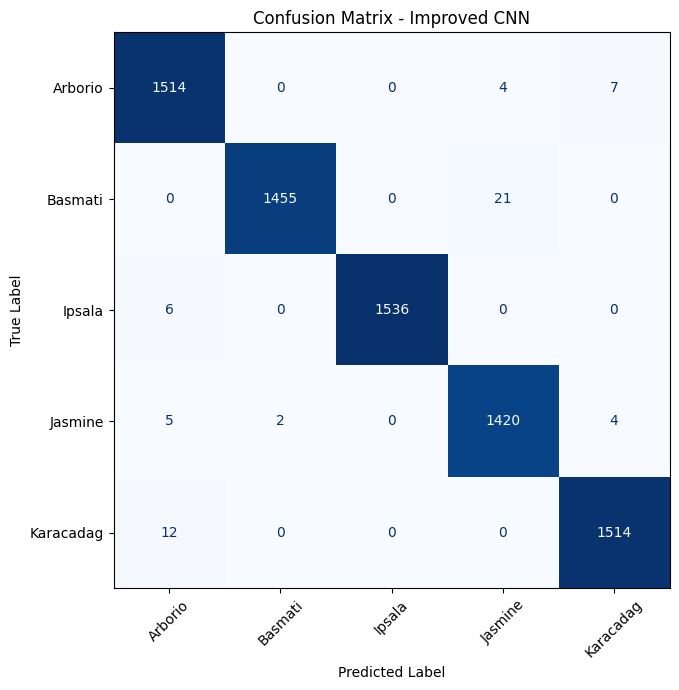

In [ ]:
# Plot the confusion matrix for the best improved model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

improved_cm = confusion_matrix(improved_y_true, improved_y_pred)

fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=improved_cm,
    display_labels=rice_classes
)

disp.plot(
    ax=ax,
    cmap='Blues',
    values_format='d',
    colorbar=False
)

plt.title('Confusion Matrix - Improved CNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Save the final improved model evaluation results to Google Drive
improved_results = {
    "test_loss": float(improved_test_loss),
    "test_accuracy": float(improved_test_accuracy),
    "correct_predictions": int(improved_correct_predictions),
    "incorrect_predictions": int(improved_incorrect_predictions),
    "total_test_images": int(len(improved_y_true)),
    "confusion_matrix": improved_cm.tolist()
}

with open('/content/drive/MyDrive/Improved_Results_Final.json', 'w') as file:
    json.dump(improved_results, file, indent=4)

print("Final improved results saved successfully.")

Final improved results saved successfully.


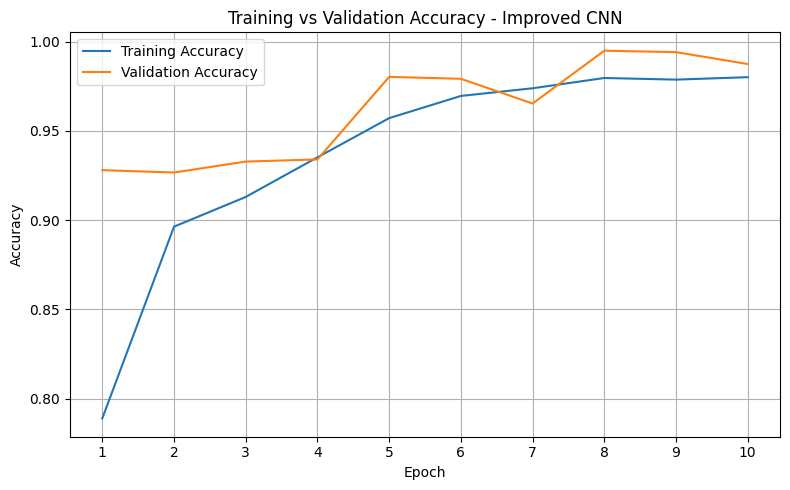

In [ ]:
# Plot training and validation accuracy for the improved CNN
epochs = range(1, len(improved_history['accuracy']) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, improved_history['accuracy'], label='Training Accuracy')
plt.plot(epochs, improved_history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy - Improved CNN')
plt.xticks(epochs)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

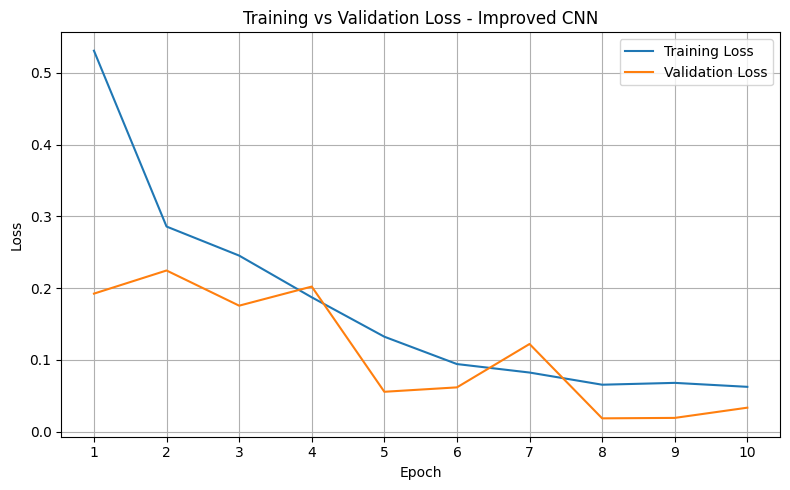

In [ ]:
# Plot training and validation loss for the improved CNN
epochs = range(1, len(improved_history['loss']) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, improved_history['loss'], label='Training Loss')
plt.plot(epochs, improved_history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss - Improved CNN')
plt.xticks(epochs)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

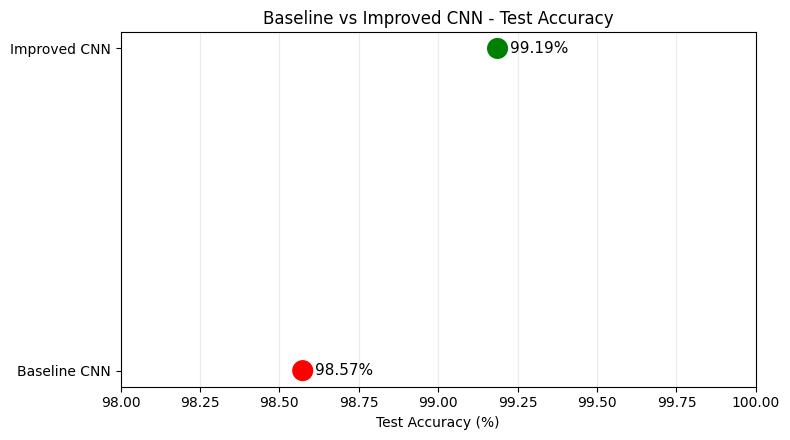

In [ ]:
# Compare saved test accuracy of the baseline and improved CNN
import json
import matplotlib.pyplot as plt

with open('/content/drive/MyDrive/Baseline_Results_Final.json', 'r') as file:
    baseline_results = json.load(file)

with open('/content/drive/MyDrive/Improved_Results_Final.json', 'r') as file:
    improved_results = json.load(file)

models = ["Baseline CNN", "Improved CNN"]
test_accuracies = [
    baseline_results["test_accuracy"] * 100,
    improved_results["test_accuracy"] * 100
]

colors = ["red", "green"]

plt.figure(figsize=(8, 4.5))

plt.scatter(
    test_accuracies,
    models,
    s=200,
    c=colors
)

for model_name, value in zip(models, test_accuracies):
    plt.text(
        value + 0.04,
        model_name,
        f"{value:.2f}%",
        va="center",
        fontsize=11
    )

plt.xlabel("Test Accuracy (%)")
plt.title("Baseline vs Improved CNN - Test Accuracy")
plt.xlim(98, 100)
plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# Collect misclassified test images from the best improved model
misclassified_images = []
misclassified_true = []
misclassified_pred = []

for images, labels in test_dataset:
    predictions = np.argmax(improved_epoch8.predict(images, verbose=0), axis=1)

    for image, true_label, pred_label in zip(images, labels.numpy(), predictions):
        if true_label != pred_label:
            misclassified_images.append(image.numpy())
            misclassified_true.append(rice_classes[true_label])
            misclassified_pred.append(rice_classes[pred_label])

print("Total misclassified images:", len(misclassified_images))

Total misclassified images: 61


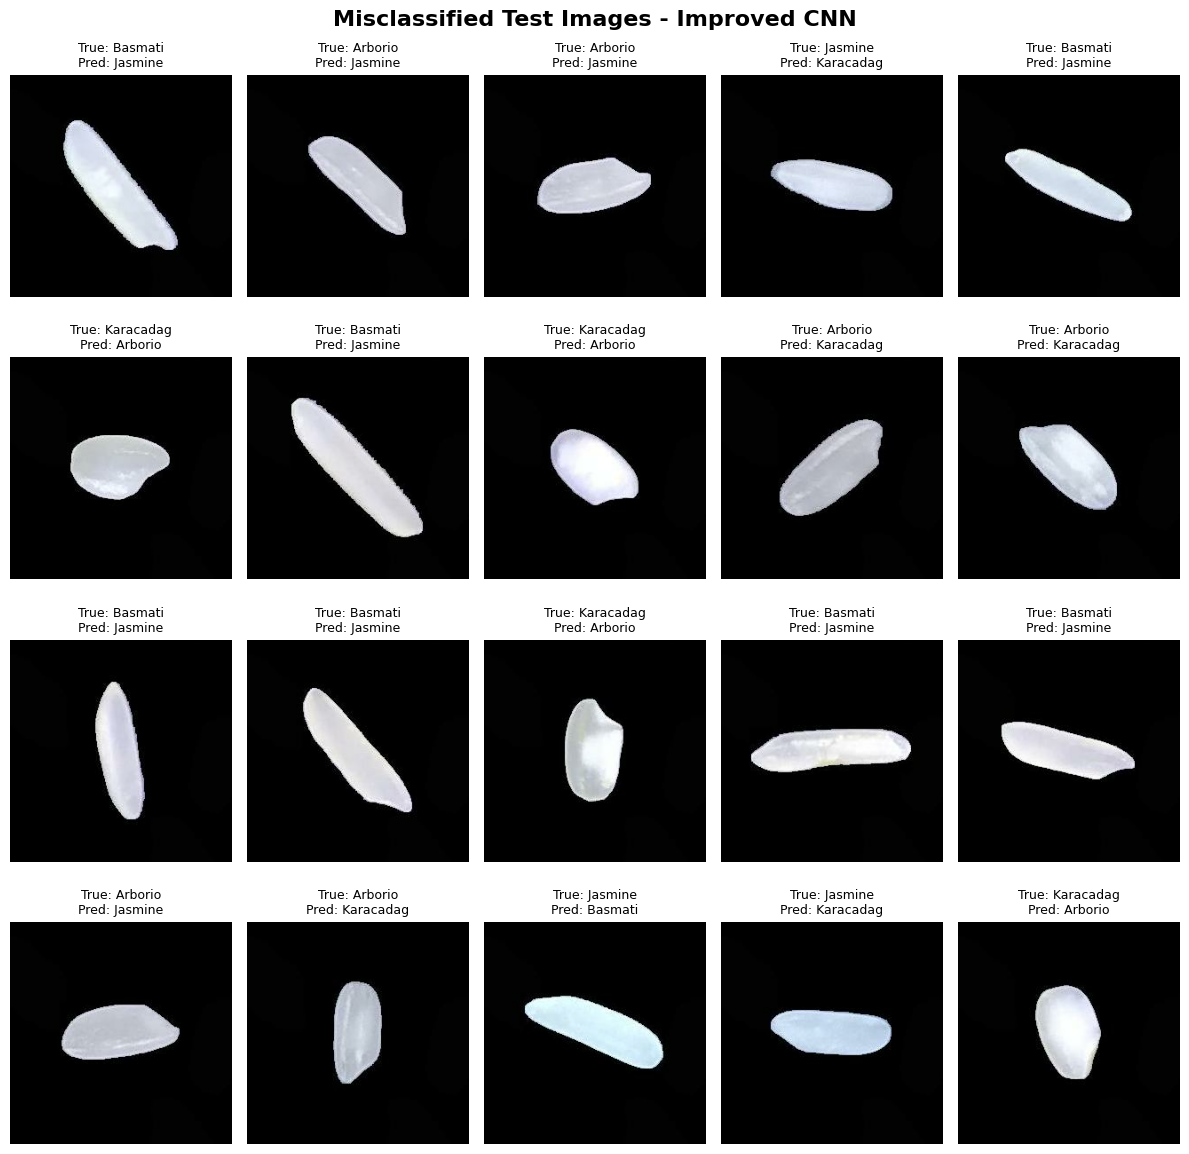

In [ ]:
# Display the first 20 misclassified images from the improved CNN
plt.figure(figsize=(12, 12))

for i in range(min(20, len(misclassified_images))):
    plt.subplot(4, 5, i + 1)
    plt.imshow(misclassified_images[i])
    plt.title(
        f"True: {misclassified_true[i]}\nPred: {misclassified_pred[i]}",
        fontsize=9
    )
    plt.axis("off")

plt.suptitle("Misclassified Test Images - Improved CNN", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Improved CNN Results

The improved CNN achieved **99.19% test accuracy** with a test loss of **0.0263**.

Out of **7,500 test images**, **7,439 images were classified correctly** and **61 images were misclassified**. Compared with the baseline CNN, which achieved **98.57% test accuracy with 107 misclassified images**, the improved CNN increased the test accuracy and reduced the number of classification errors by **46 images**.

A major improvement was observed in model efficiency. The baseline CNN contained **30,502,597 trainable parameters**, while the improved CNN contained only **110,405 trainable parameters**, representing an approximately **99.64% reduction**. This significant reduction was mainly achieved by replacing the Flatten layer with Global Average Pooling. Despite using far fewer parameters, the improved CNN achieved better test performance than the baseline model.

The classification report showed strong performance across all five rice classes, with F1-scores close to or above **0.99** for most classes.

According to the confusion matrix, the most frequent error occurred between **Basmati and Jasmine**, where 21 Basmati images were classified as Jasmine. Some confusion was also observed between **Karacadag and Arborio**.

The analysis of misclassified images showed that many incorrectly classified rice grains have similar visual characteristics to the predicted classes. For example, some Basmati and Jasmine grains have similar long and narrow shapes, while some Arborio and Karacadag samples have similar shorter and wider appearances. These similarities may contribute to the remaining classification errors.

The training curves showed that the best validation performance was achieved at **Epoch 8**, with a validation accuracy of **99.49%**. Therefore, the model saved at Epoch 8 was selected for final test evaluation.

Overall, the improved CNN achieved **higher test accuracy, lower test loss, fewer classification errors, and approximately 99.64% fewer parameters** compared with the baseline CNN. These results demonstrate that the improved architecture provides better classification performance while being significantly more parameter-efficient.

## CNN Model with Data Augmentation

In this model, data augmentation is applied to the improved CNN architecture using random horizontal flipping, rotation, and zoom transformations.

The purpose of adding data augmentation is to increase the diversity of the training data and evaluate whether these transformations can improve the model's generalization ability and classification performance on unseen test images.

The architecture of the CNN remains the same as the improved CNN model, allowing the effect of data augmentation to be evaluated independently.

In [ ]:
# Clear the previous Keras session before building a new model
tf.keras.backend.clear_session()

In [ ]:
# Build the CNN model with lighter data augmentation
model_augmented = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(250, 250, 3)),

    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(5, activation='softmax')
], name='Augmented_Rice_CNN')

model_augmented.summary()

Model: "Augmented_Rice_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 250, 250, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 248, 248, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 124, 124, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 59, 59, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the augmented CNN model
model_augmented.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
# Save the augmented model after every training epoch
augmented_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/Augmented_Epoch_{epoch:02d}.keras',
    save_freq='epoch',
    save_best_only=False,
    verbose=1
)

In [ ]:
# Train the augmented CNN and save every epoch
training_history_augmented = model_augmented.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[augmented_checkpoint]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5697 - loss: 0.9381
Epoch 1: saving model to /content/drive/MyDrive/Augmented_Epoch_01.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Augmented_Epoch_01.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 137s 69ms/step - accuracy: 0.7279 - loss: 0.6389 - val_accuracy: 0.5920 - val_loss: 1.3537
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8810 - loss: 0.3241
Epoch 2: saving model to /content/drive/MyDrive/Augmented_Epoch_02.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Augmented_Epoch_02.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 132s 70ms/step - accuracy: 0.8890 - loss: 0.3037 - val_accuracy: 0.5501 - val_loss: 1.4729
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9165 - loss: 0.2400
Epoch 3: saving model to /content/drive/MyDrive/Augmented_Epoch_03.keras

Epoch 3: finished saving model to /content/drive/MyDrive/Augmented_Epoch_03.keras
1875/1875 ━━━━━━━━━━━

In [ ]:
# Save the augmented CNN training history to Google Drive
import json

augmented_history_path = '/content/drive/MyDrive/Augmented_Training_History_Final.json'

with open(augmented_history_path, 'w') as file:
    json.dump(training_history_augmented.history, file, indent=4)

print("Augmented training history saved successfully.")

Augmented training history saved successfully.


In [ ]:
# Load the saved training history and find the best epoch
import json

with open('/content/drive/MyDrive/Augmented_Training_History_Final.json', 'r') as file:
    augmented_history = json.load(file)

best_augmented_epoch = np.argmax(augmented_history['val_accuracy']) + 1
best_augmented_val_accuracy = max(augmented_history['val_accuracy'])

print("Best Epoch:", best_augmented_epoch)
print(f"Best Validation Accuracy: {best_augmented_val_accuracy * 100:.2f}%")

Best Epoch: 10
Best Validation Accuracy: 99.23%


In [ ]:
# Load the saved model from the best epoch
augmented_epoch10 = tf.keras.models.load_model(
    '/content/drive/MyDrive/Augmented_Epoch_10.keras'
)

In [ ]:
# Evaluate the best augmented model on the test dataset
augmented_test_loss, augmented_test_accuracy = augmented_epoch10.evaluate(test_dataset)

print(f"Test Loss: {augmented_test_loss:.4f}")
print(f"Test Accuracy: {augmented_test_accuracy:.4f}")
print(f"Test Accuracy (%): {augmented_test_accuracy * 100:.2f}%")

235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.9912 - loss: 0.0330
Test Loss: 0.0330
Test Accuracy: 0.9912
Test Accuracy (%): 99.12%


In [ ]:
# Generate predictions using the best augmented model
augmented_y_true = np.concatenate([
    labels.numpy() for images, labels in test_dataset
])

augmented_y_pred = np.argmax(
    augmented_epoch10.predict(test_dataset),
    axis=1
)

235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step


In [ ]:
# Count correct and incorrect predictions for the best augmented model
augmented_correct_predictions = np.sum(augmented_y_true == augmented_y_pred)
augmented_incorrect_predictions = np.sum(augmented_y_true != augmented_y_pred)

print("Correct predictions:", augmented_correct_predictions)
print("Incorrect predictions:", augmented_incorrect_predictions)
print("Total test images:", len(augmented_y_true))

Correct predictions: 7434
Incorrect predictions: 66
Total test images: 7500


In [ ]:
# Generate the classification report for the best augmented model
from sklearn.metrics import classification_report

print(classification_report(
    augmented_y_true,
    augmented_y_pred,
    target_names=rice_classes,
    digits=4
))

              precision    recall  f1-score   support

     Arborio     0.9857    0.9921    0.9889      1525
     Basmati     0.9993    0.9810    0.9901      1476
      Ipsala     1.0000    1.0000    1.0000      1542
     Jasmine     0.9728    0.9979    0.9852      1431
   Karacadag     0.9980    0.9849    0.9914      1526

    accuracy                         0.9912      7500
   macro avg     0.9911    0.9912    0.9911      7500
weighted avg     0.9913    0.9912    0.9912      7500



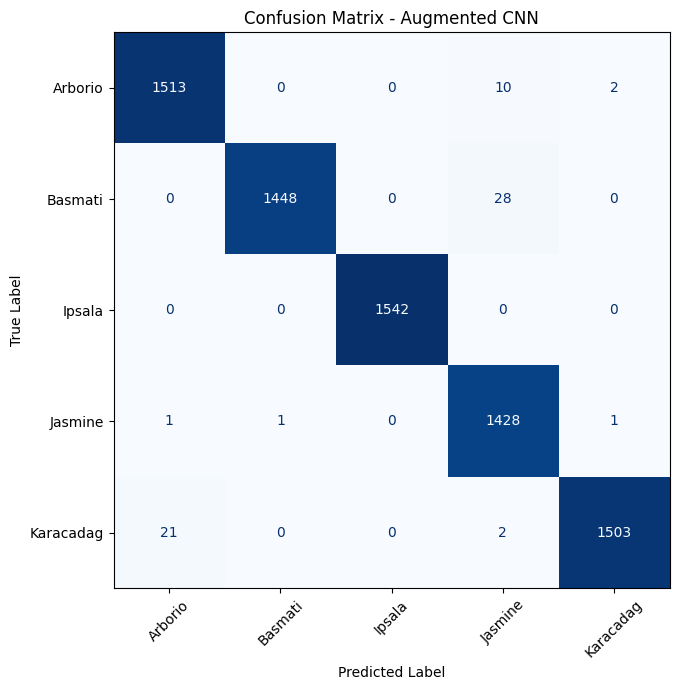

In [ ]:
# Plot the confusion matrix for the best augmented model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

augmented_cm = confusion_matrix(augmented_y_true, augmented_y_pred)

fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=augmented_cm,
    display_labels=rice_classes
)

disp.plot(
    ax=ax,
    cmap='Blues',
    values_format='d',
    colorbar=False
)

plt.title('Confusion Matrix - Augmented CNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Save the final augmented model evaluation results to Google Drive
augmented_results = {
    "test_loss": float(augmented_test_loss),
    "test_accuracy": float(augmented_test_accuracy),
    "correct_predictions": int(augmented_correct_predictions),
    "incorrect_predictions": int(augmented_incorrect_predictions),
    "total_test_images": int(len(augmented_y_true)),
    "confusion_matrix": augmented_cm.tolist()
}

with open('/content/drive/MyDrive/Augmented_Results_Final.json', 'w') as file:
    json.dump(augmented_results, file, indent=4)

print("Final augmented results saved successfully.")

Final augmented results saved successfully.


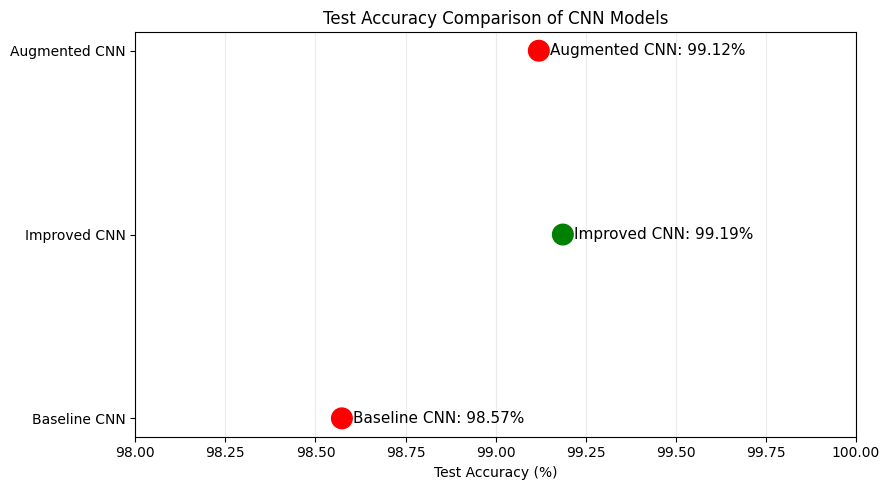

In [ ]:
# Compare saved test accuracy of all three CNN models
import json
import matplotlib.pyplot as plt

with open('/content/drive/MyDrive/Baseline_Results_Final.json', 'r') as file:
    baseline_results = json.load(file)

with open('/content/drive/MyDrive/Improved_Results_Final.json', 'r') as file:
    improved_results = json.load(file)

with open('/content/drive/MyDrive/Augmented_Results_Final.json', 'r') as file:
    augmented_results = json.load(file)

models = ["Baseline CNN", "Improved CNN", "Augmented CNN"]

test_accuracies = [
    baseline_results["test_accuracy"] * 100,
    improved_results["test_accuracy"] * 100,
    augmented_results["test_accuracy"] * 100
]

best_index = test_accuracies.index(max(test_accuracies))

colors = ["red", "orange", "red"]
colors[best_index] = "green"

plt.figure(figsize=(9, 5))

plt.scatter(
    test_accuracies,
    models,
    s=220,
    c=colors
)

for model_name, value in zip(models, test_accuracies):
    plt.text(
        value + 0.03,
        model_name,
        f"{model_name}: {value:.2f}%",
        va="center",
        fontsize=11
    )

plt.xlabel("Test Accuracy (%)")
plt.title("Test Accuracy Comparison of CNN Models")
plt.xlim(98, 100)
plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## Augmented CNN Results

The augmented CNN achieved **99.12% test accuracy** with a test loss of **0.0330**.

Out of **7,500 test images**, **7,434 images were classified correctly** and **66 images were misclassified**. Compared with the improved CNN, which achieved **99.19% test accuracy with 61 misclassified images**, the augmented model showed a slightly lower test accuracy and produced **5 additional classification errors**. However, compared with the baseline CNN, the number of misclassified images was reduced from **107 to 66**.

The augmented CNN contained **110,405 trainable parameters**, which is the same as the improved CNN and approximately **99.64% fewer parameters than the baseline CNN**. The architecture was kept unchanged from the improved CNN, allowing the effect of data augmentation to be evaluated independently.

The classification report demonstrated strong performance across all five rice classes. Ipsala achieved the highest F1-score of **1.0000**, while Jasmine achieved the lowest F1-score of **0.9852**.

According to the confusion matrix, the most frequent error occurred between **Basmati and Jasmine**, where 28 Basmati images were classified as Jasmine. Another noticeable confusion was observed between **Karacadag and Arborio**, where 21 Karacadag images were classified as Arborio.

In this experiment, lighter data augmentation techniques, including random horizontal flipping, rotation, and zoom, were applied during training. The best validation performance was achieved at **Epoch 10**, with a validation accuracy of **99.23%**. Therefore, the model saved at Epoch 10 was selected for final test evaluation.

Compared with the improved CNN, data augmentation did not provide additional improvement in this experiment. The test accuracy slightly decreased from **99.19% to 99.12%**, and the number of misclassified images increased from **61 to 66**. Despite this small difference, the augmented model maintained strong classification performance.

Overall, the three CNN models achieved high accuracy on the rice classification task. The transition from the baseline CNN to the improved CNN resulted in significant improvements in both accuracy and parameter efficiency, while the addition of lighter data augmentation did not further improve the final test performance in this experiment.

## Improve2 CNN Model

In this experiment, a deeper CNN architecture is introduced to further investigate whether increasing the feature extraction capacity of the network can improve rice classification performance.

Compared with the previous Improved CNN model, an additional convolutional layer with **256 filters** is added. Furthermore, `padding='same'` is applied in the convolutional layers to preserve spatial dimensions before pooling operations.

Global Average Pooling is retained to control the number of trainable parameters, while Dropout is used to reduce the risk of overfitting and improve model generalization.

The objective of this model is to evaluate whether a deeper feature extraction architecture can achieve better classification performance while maintaining efficient parameter usage and strong generalization ability.

In [ ]:
# Clear the previous Keras session before building a new model
tf.keras.backend.clear_session()

In [ ]:
# Build the final Improve2 CNN model without Batch Normalization
improve2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(250, 250, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(5, activation='softmax')
], name='Improve2_CNN')

improve2.summary()

Model: "Improve2_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 250, 250, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 125, 125, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 31, 31, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,957 (1.61 MB)

 Trainable params: 421,957 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the Improve2 CNN model
improve2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Define callbacks to control training and reduce overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [ ]:
# Save the Improve2 model after every training epoch
improve2_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/Improve2_Epoch_{epoch:02d}.keras',
    save_freq='epoch',
    save_best_only=False,
    verbose=1
)

In [ ]:
# Train the final Improve2 CNN model
history_improve2 = improve2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40,
    callbacks=[early_stopping, reduce_lr, improve2_checkpoint]
)

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6685 - loss: 0.7385
Epoch 1: saving model to /content/drive/MyDrive/Improve2_Epoch_01.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Improve2_Epoch_01.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 159s 85ms/step - accuracy: 0.8212 - loss: 0.4330 - val_accuracy: 0.9533 - val_loss: 0.1262 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9426 - loss: 0.1699
Epoch 2: saving model to /content/drive/MyDrive/Improve2_Epoch_02.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Improve2_Epoch_02.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 156s 83ms/step - accuracy: 0.9521 - loss: 0.1426 - val_accuracy: 0.9869 - val_loss: 0.0391 - learning_rate: 0.0010
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9709 - loss: 0.0873
Epoch 3: saving model to /content/drive/MyDrive/Improve2_Epoch_03.keras

Epoch 3: finished saving model to /content/drive/MyDrive/Imp

In [ ]:
# Load the best Improve2 model from the best epoch
improve2_best = tf.keras.models.load_model(
    '/content/drive/MyDrive/Improve2_Epoch_31.keras'
)

print("Best Improve2 model loaded successfully.")

Best Improve2 model loaded successfully.


In [ ]:
# Check the saved Improve2 checkpoints
import glob

saved_checkpoints = sorted(
    glob.glob('/content/drive/MyDrive/Improve2_Epoch_*.keras')
)

print("Number of saved checkpoints:", len(saved_checkpoints))
print("Last checkpoint:", saved_checkpoints[-1])

Number of saved checkpoints: 40
Last checkpoint: /content/drive/MyDrive/Improve2_Epoch_40.keras


In [ ]:
# Evaluate the best Improve2 model on the test dataset

improve2_test_loss, improve2_test_accuracy = improve2_best.evaluate(test_dataset)

print(f"Test Loss: {improve2_test_loss:.4f}")
print(f"Test Accuracy: {improve2_test_accuracy:.4f}")
print(f"Test Accuracy (%): {improve2_test_accuracy * 100:.2f}%")

235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9980 - loss: 0.0068
Test Loss: 0.0068
Test Accuracy: 0.9980
Test Accuracy (%): 99.80%


In [ ]:
# Save the final Improve2 model evaluation results to Google Drive
import json

improve2_results = {
    "test_loss": float(improve2_test_loss),
    "test_accuracy": float(improve2_test_accuracy)
}

with open('/content/drive/MyDrive/Improve2_Results_Final.json', 'w') as file:
    json.dump(improve2_results, file, indent=4)

print("Final Improve2 results saved successfully.")

Final Improve2 results saved successfully.


In [ ]:
# Generate predictions using the best Improve2 model

improve2_y_true = np.concatenate([
    labels.numpy() for images, labels in test_dataset
])

improve2_y_pred = np.argmax(
    improve2_best.predict(test_dataset),
    axis=1
)

235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step


In [ ]:
# Count correct and incorrect predictions for the best Improve2 model

improve2_correct_predictions = np.sum(improve2_y_true == improve2_y_pred)
improve2_incorrect_predictions = np.sum(improve2_y_true != improve2_y_pred)

print("Correct predictions:", improve2_correct_predictions)
print("Incorrect predictions:", improve2_incorrect_predictions)
print("Total test images:", len(improve2_y_true))

Correct predictions: 7485
Incorrect predictions: 15
Total test images: 7500


In [ ]:
# Generate the classification report for the best Improve2 model

from sklearn.metrics import classification_report

print(classification_report(
    improve2_y_true,
    improve2_y_pred,
    target_names=rice_classes,
    digits=4
))

              precision    recall  f1-score   support

     Arborio     0.9961    0.9961    0.9961      1525
     Basmati     0.9980    1.0000    0.9990      1476
      Ipsala     1.0000    0.9994    0.9997      1542
     Jasmine     0.9979    0.9965    0.9972      1431
   Karacadag     0.9980    0.9980    0.9980      1526

    accuracy                         0.9980      7500
   macro avg     0.9980    0.9980    0.9980      7500
weighted avg     0.9980    0.9980    0.9980      7500



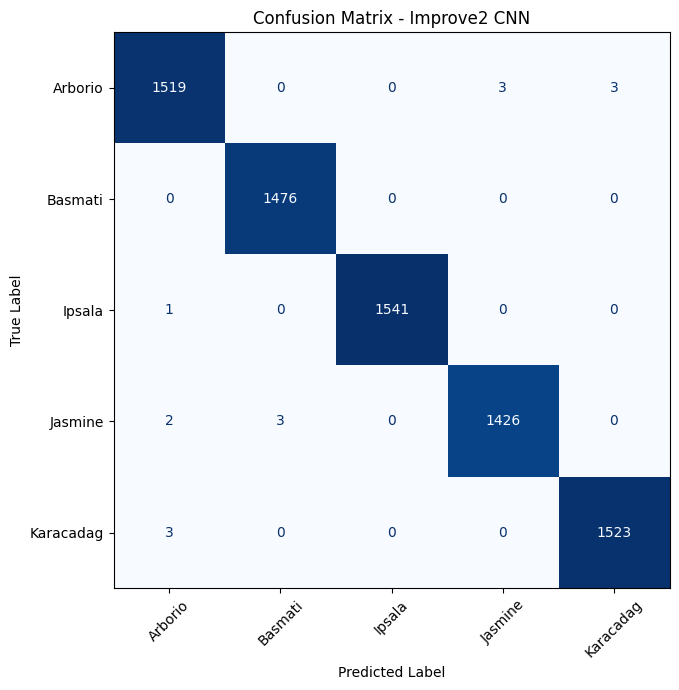

In [ ]:
# Plot the confusion matrix for the best Improve2 model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

improve2_cm = confusion_matrix(
    improve2_y_true,
    improve2_y_pred
)

fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=improve2_cm,
    display_labels=rice_classes
)

disp.plot(
    ax=ax,
    cmap='Blues',
    values_format='d',
    colorbar=False
)

plt.title('Confusion Matrix - Improve2 CNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Load the best Improve2 model (Epoch 31)

import tensorflow as tf

improve2_best = tf.keras.models.load_model(
    '/content/drive/MyDrive/Improve2_Epoch_31.keras'
)

print("Best Improve2 model loaded successfully.")

Best Improve2 model loaded successfully.


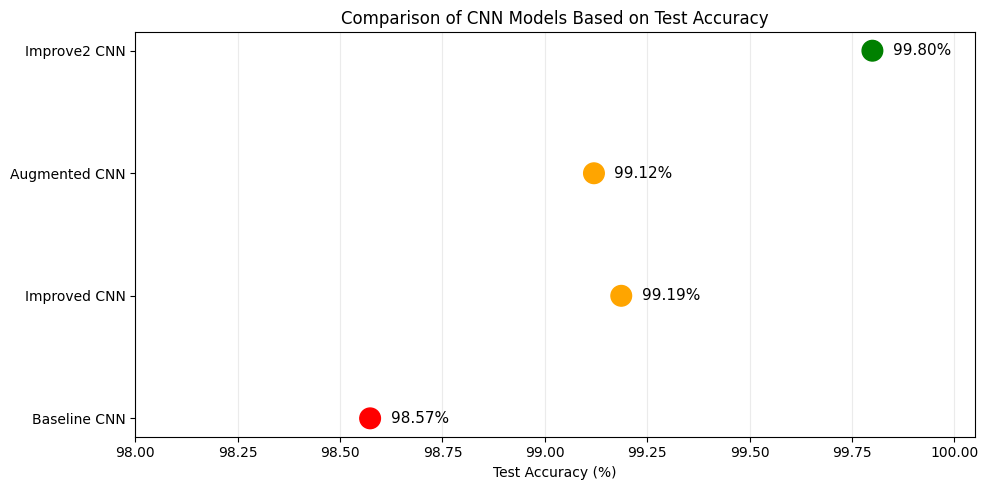

In [ ]:
# Final clean CNN accuracy comparison plot

import json
import matplotlib.pyplot as plt

# Load saved results

with open('/content/drive/MyDrive/Baseline_Results_Final.json', 'r') as file:
    baseline_results = json.load(file)

with open('/content/drive/MyDrive/Improved_Results_Final.json', 'r') as file:
    improved_results = json.load(file)

with open('/content/drive/MyDrive/Augmented_Results_Final.json', 'r') as file:
    augmented_results = json.load(file)

with open('/content/drive/MyDrive/Improve2_Results_Final.json', 'r') as file:
    improve2_results = json.load(file)


# Model names

models = [
    "Baseline CNN",
    "Improved CNN",
    "Augmented CNN",
    "Improve2 CNN"
]


# Test accuracy values

accuracy = [
    baseline_results["test_accuracy"] * 100,
    improved_results["test_accuracy"] * 100,
    augmented_results["test_accuracy"] * 100,
    improve2_results["test_accuracy"] * 100
]


# Colors (best model = green)

colors = [
    "red",
    "orange",
    "orange",
    "green"
]


# Plot

plt.figure(figsize=(10, 5))

plt.scatter(
    accuracy,
    models,
    s=220,
    c=colors
)


# Add labels with more distance

for model, acc in zip(models, accuracy):
    plt.text(
        acc + 0.05,
        model,
        f"{acc:.2f}%",
        va="center",
        fontsize=11
    )


plt.xlabel("Test Accuracy (%)")

plt.title("Comparison of CNN Models Based on Test Accuracy")

plt.xlim(98, 100.05)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.show()

In [ ]:
# Load the best Improve2 model
improve2_best = tf.keras.models.load_model(
    '/content/drive/MyDrive/Improve2_Epoch_31.keras'
)

print("Improve2 Epoch 31 loaded successfully.")

Improve2 Epoch 31 loaded successfully.


In [ ]:
# Collect all misclassified test images from the best Improve2 model
misclassified_images = []
misclassified_true = []
misclassified_pred = []

for images, labels in test_dataset:
    predictions = improve2_best(images, training=False)
    predicted_labels = np.argmax(predictions.numpy(), axis=1)
    true_labels = labels.numpy()

    wrong_indices = np.where(predicted_labels != true_labels)[0]

    for i in wrong_indices:
        misclassified_images.append(images[i].numpy())
        misclassified_true.append(true_labels[i])
        misclassified_pred.append(predicted_labels[i])

print("Total misclassified images:", len(misclassified_images))

Total misclassified images: 15


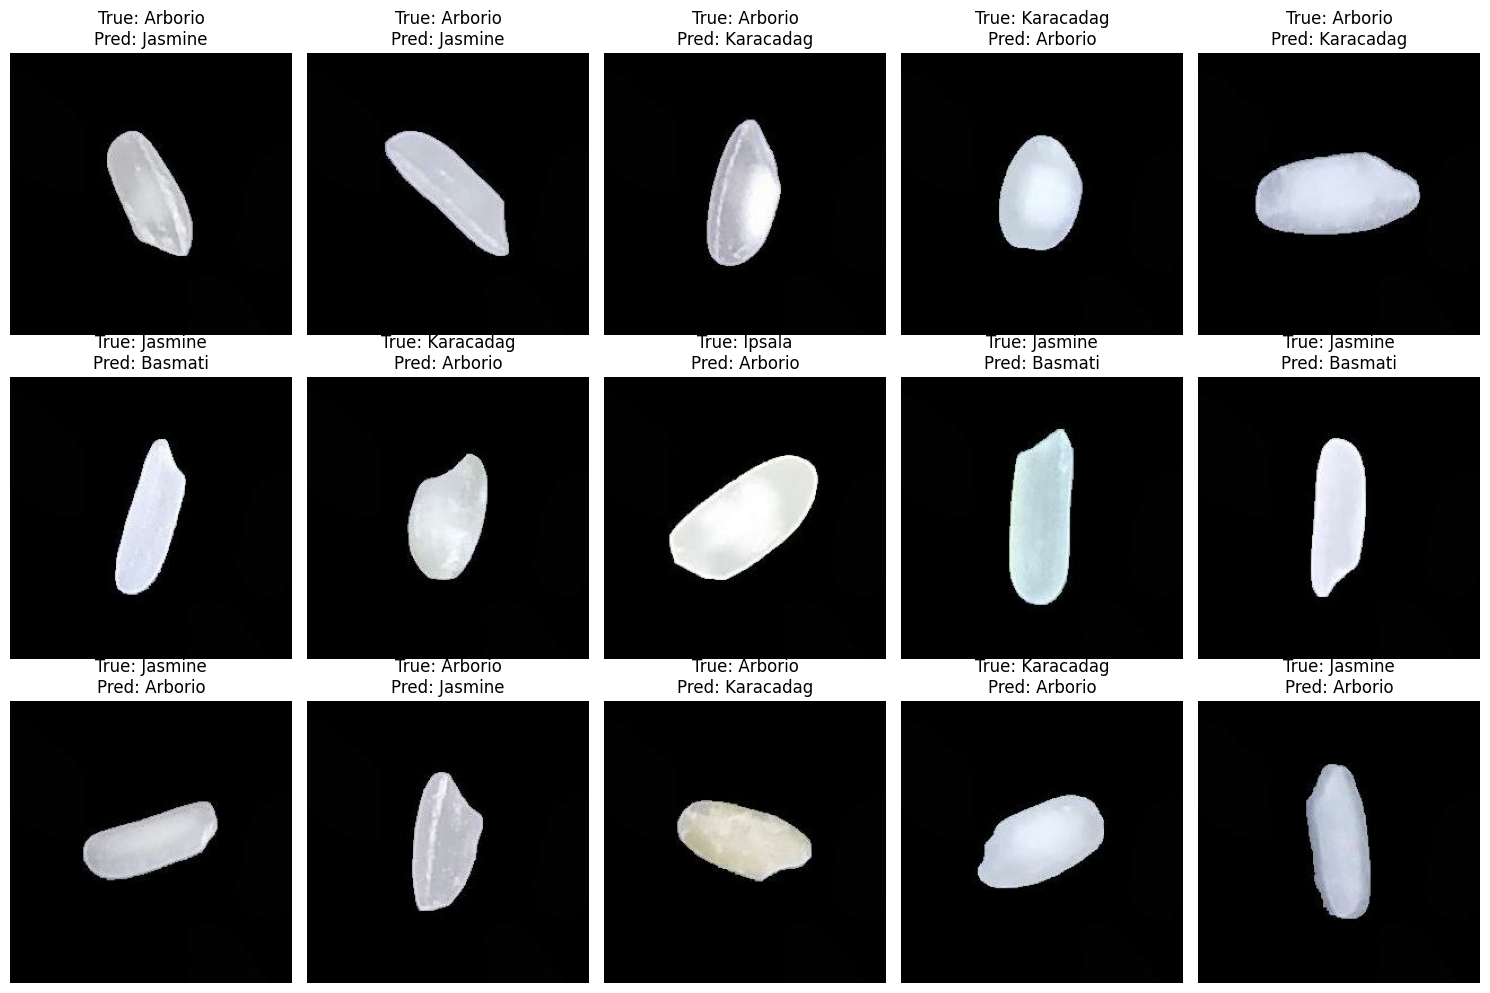

In [ ]:
# Display all misclassified images with their true and predicted classes
plt.figure(figsize=(15, 10))

for i in range(len(misclassified_images)):
    plt.subplot(3, 5, i + 1)
    plt.imshow(misclassified_images[i])
    plt.title(
        f"True: {rice_classes[misclassified_true[i]]}\n"
        f"Pred: {rice_classes[misclassified_pred[i]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## ResNet50 Transfer Learning

In this experiment, ResNet50 with pretrained ImageNet weights is used to evaluate the performance of transfer learning for rice image classification.

The original classification layers of ResNet50 are removed, while the pretrained convolutional base is initially frozen and used as a feature extractor. New classification layers are then added to classify the five rice varieties.

Since the pretrained ResNet50 model expects a specific input preprocessing method, separate datasets are prepared using the ResNet50 `preprocess_input` function.

The objective of this experiment is to compare the performance of a pretrained deep learning model with the custom CNN architectures developed in the previous experiments.

In [ ]:
# Prepare datasets using the preprocessing required by ResNet50
def preprocess_resnet(image, label):
    image = image * 255.0
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

resnet_train_dataset = train_dataset.map(preprocess_resnet)
resnet_val_dataset = val_dataset.map(preprocess_resnet)
resnet_test_dataset = test_dataset.map(preprocess_resnet)

In [ ]:
# Build a ResNet50 model with pretrained ImageNet weights
base_model = tf.keras.applications.ResNet50(
weights="imagenet",
include_top=False,
input_shape=(250, 250, 3)
)

base_model.trainable = False

resnet_model = tf.keras.Sequential([
base_model,
tf.keras.layers.GlobalAveragePooling2D(),
tf.keras.layers.Dense(128, activation="relu"),
tf.keras.layers.Dense(5, activation="softmax")
], name="ResNet50_Rice")

resnet_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "ResNet50_Rice"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Compile the ResNet50 model
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Save the ResNet50 model after each epoch
resnet_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/ResNet50_Epoch_{epoch:02d}.keras",
    save_weights_only=False,
    save_freq="epoch",
    verbose=1
)

In [ ]:
# Train the ResNet50 transfer learning model
history_resnet = resnet_model.fit(
    resnet_train_dataset,
    validation_data=resnet_val_dataset,
    epochs=10,
    callbacks=[resnet_checkpoint]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9625 - loss: 0.1085
Epoch 1: saving model to /content/drive/MyDrive/ResNet50_Epoch_01.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ResNet50_Epoch_01.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 284s 146ms/step - accuracy: 0.9815 - loss: 0.0550 - val_accuracy: 0.9903 - val_loss: 0.0259
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9900 - loss: 0.0295
Epoch 2: saving model to /content/drive/MyDrive/ResNet50_Epoch_02.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ResNet50_Epoch_02.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 270s 143ms/step - accuracy: 0.9902 - loss: 0.0297 - val_accuracy: 0.9696 - val_loss: 0.0948
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9909 - loss: 0.0254
Epoch 3: saving model to /content/drive/MyDrive/ResNet50_Epoch_03.keras

Epoch 3: finished saving model to /content/drive/MyDrive/ResNet50_Epoch_03.keras
1875/1875 ━━━━━━━━━━━━

In [ ]:
# Save the complete ResNet50 training history for later analysis and plots
import json

resnet_history = history_resnet.history

with open("/content/drive/MyDrive/ResNet50_Training_History_Final.json", "w") as file:
    json.dump(resnet_history, file)

print("ResNet50 complete training history saved successfully.")
print(resnet_history.keys())

ResNet50 complete training history saved successfully.
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
# Find the best ResNet50 epoch based on validation accuracy
best_resnet_epoch = np.argmax(resnet_history["val_accuracy"]) + 1
best_resnet_val_accuracy = max(resnet_history["val_accuracy"])
best_resnet_val_loss = resnet_history["val_loss"][best_resnet_epoch - 1]

print("Best ResNet50 Epoch:", best_resnet_epoch)
print(f"Best Validation Accuracy: {best_resnet_val_accuracy * 100:.2f}%")
print(f"Validation Loss at Best Epoch: {best_resnet_val_loss:.4f}")

Best ResNet50 Epoch: 7
Best Validation Accuracy: 99.71%
Validation Loss at Best Epoch: 0.0078


In [ ]:
# Load the best previous ResNet50 model (Epoch 7)
resnet_best = tf.keras.models.load_model(
    "/content/drive/MyDrive/ResNet50_Epoch_07.keras"
)

print("Previous best ResNet50 loaded successfully.")

Previous best ResNet50 loaded successfully.


In [ ]:
# Evaluate the best ResNet50 model on the test dataset
resnet_test_loss, resnet_test_accuracy = resnet_best.evaluate(
    resnet_test_dataset
)

print(f"ResNet50 Test Loss: {resnet_test_loss:.4f}")
print(f"ResNet50 Test Accuracy: {resnet_test_accuracy * 100:.2f}%")

235/235 ━━━━━━━━━━━━━━━━━━━━ 37s 136ms/step - accuracy: 0.9964 - loss: 0.0102
ResNet50 Test Loss: 0.0102
ResNet50 Test Accuracy: 99.64%


In [ ]:
# Generate predictions for the ResNet50 test dataset
resnet_y_true = []
resnet_y_pred = []

for images, labels in resnet_test_dataset:
    predictions = resnet_best(images, training=False)
    predicted_labels = np.argmax(predictions.numpy(), axis=1)

    resnet_y_true.extend(labels.numpy())
    resnet_y_pred.extend(predicted_labels)

resnet_y_true = np.array(resnet_y_true)
resnet_y_pred = np.array(resnet_y_pred)

print("Total test images:", len(resnet_y_true))

Total test images: 7500


In [ ]:
# Count correct and incorrect ResNet50 predictions
resnet_correct_predictions = np.sum(resnet_y_true == resnet_y_pred)
resnet_incorrect_predictions = np.sum(resnet_y_true != resnet_y_pred)

print("Correct Predictions:", resnet_correct_predictions)
print("Incorrect Predictions:", resnet_incorrect_predictions)
print("Total Test Images:", len(resnet_y_true))

Correct Predictions: 7473
Incorrect Predictions: 27
Total Test Images: 7500


In [ ]:
# Generate the ResNet50 classification report
from sklearn.metrics import classification_report

resnet_classification_report = classification_report(
    resnet_y_true,
    resnet_y_pred,
    target_names=rice_classes,
    digits=4
)

print(resnet_classification_report)

              precision    recall  f1-score   support

     Arborio     0.9935    0.9980    0.9957      1525
     Basmati     0.9993    0.9925    0.9959      1476
      Ipsala     0.9994    0.9981    0.9987      1542
     Jasmine     0.9903    0.9979    0.9941      1431
   Karacadag     0.9993    0.9954    0.9974      1526

    accuracy                         0.9964      7500
   macro avg     0.9964    0.9964    0.9964      7500
weighted avg     0.9964    0.9964    0.9964      7500



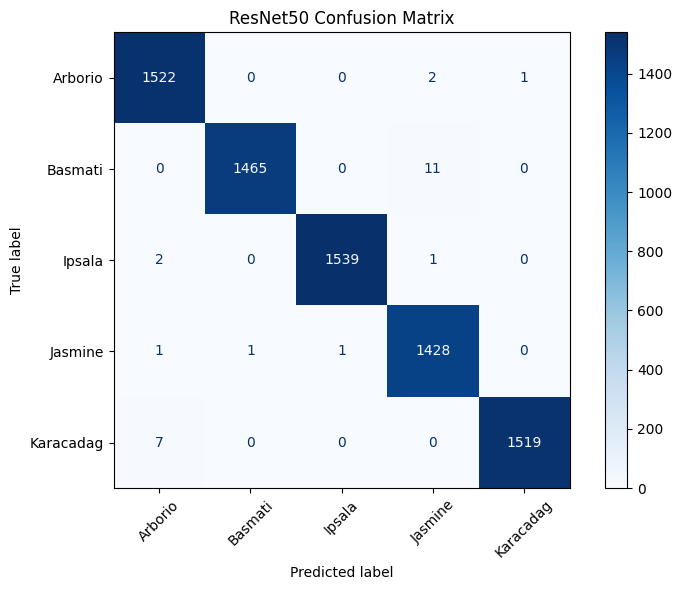

In [ ]:
# Plot the ResNet50 confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=resnet_cm,
    display_labels=rice_classes
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("ResNet50 Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Save the complete ResNet50 test results for later analysis and comparison
import json

resnet_results = {
    "best_epoch": int(best_resnet_epoch),
    "best_val_accuracy": float(best_resnet_val_accuracy),
    "best_val_loss": float(best_resnet_val_loss),
    "test_loss": float(resnet_test_loss),
    "test_accuracy": float(resnet_test_accuracy),
    "correct_predictions": int(resnet_correct_predictions),
    "incorrect_predictions": int(resnet_incorrect_predictions),
    "total_test_images": int(len(resnet_y_true)),
    "confusion_matrix": resnet_cm.tolist()
}

with open("/content/drive/MyDrive/ResNet50_Results_Final.json", "w") as file:
    json.dump(resnet_results, file, indent=4)

print("ResNet50 complete results saved successfully.")

ResNet50 complete results saved successfully.


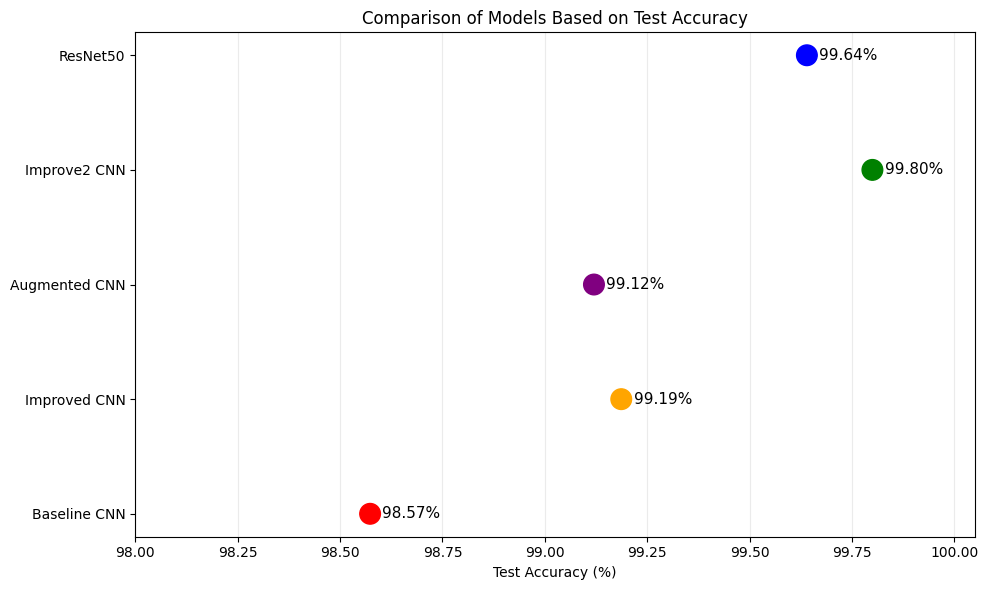

In [ ]:
# Final model accuracy comparison plot

import json
import matplotlib.pyplot as plt

# Load saved results
with open('/content/drive/MyDrive/Baseline_Results_Final.json', 'r') as file:
    baseline_results = json.load(file)

with open('/content/drive/MyDrive/Improved_Results_Final.json', 'r') as file:
    improved_results = json.load(file)

with open('/content/drive/MyDrive/Augmented_Results_Final.json', 'r') as file:
    augmented_results = json.load(file)

with open('/content/drive/MyDrive/Improve2_Results_Final.json', 'r') as file:
    improve2_results = json.load(file)

with open('/content/drive/MyDrive/ResNet50_Results_Final.json', 'r') as file:
    resnet_results = json.load(file)


# Model names
models = [
    "Baseline CNN",
    "Improved CNN",
    "Augmented CNN",
    "Improve2 CNN",
    "ResNet50"
]


# Test accuracy values
accuracy = [
    baseline_results["test_accuracy"] * 100,
    improved_results["test_accuracy"] * 100,
    augmented_results["test_accuracy"] * 100,
    improve2_results["test_accuracy"] * 100,
    resnet_results["test_accuracy"] * 100
]


# Different color for each model
colors = [
    "red",
    "orange",
    "purple",
    "green",
    "blue"
]


# Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    accuracy,
    models,
    s=220,
    c=colors
)


# Add accuracy labels
for model, acc in zip(models, accuracy):
    plt.text(
        acc + 0.03,
        model,
        f"{acc:.2f}%",
        va="center",
        fontsize=11
    )


plt.xlabel("Test Accuracy (%)")

plt.title("Comparison of Models Based on Test Accuracy")

plt.xlim(98, 100.05)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.show()

Overall Summary
In this project, several CNN models were developed and tested for rice image classification. Starting from a simple baseline CNN, the models were gradually improved by changing the architecture, using Global Average Pooling, Dropout, data augmentation, and deeper convolutional layers. A ResNet50 transfer learning model with ImageNet pretrained weights was also evaluated.
Overall, all models achieved strong results, with test accuracy improving from 98.57% for the baseline CNN to 99.80% for the Improve2 CNN. The Improved CNN reached 99.19%, the Augmented CNN achieved 99.12%, and ResNet50 achieved 99.64%.
Interestingly, data augmentation did not improve the result compared with the Improved CNN in this experiment. ResNet50 performed very well, but the custom Improve2 CNN still achieved the highest test accuracy. This shows that a carefully designed CNN can perform extremely well on this dataset without requiring a large pretrained architecture.
Overall, the experiments show how changes in model architecture and training strategy can affect classification performance, and the final models were able to distinguish the five rice varieties with very high accuracy.

## ResNet50 Fine-Tuning

In this experiment, the pretrained ResNet50 model is fine-tuned to investigate whether allowing some of the pretrained layers to adapt to the rice dataset can further improve classification performance.

Unlike the previous ResNet50 experiment, where the entire convolutional base was frozen, selected deeper layers of ResNet50 will be unfrozen and trained using a small learning rate.

The objective is to determine whether fine-tuning can improve the performance of the pretrained model while preserving the useful features learned from ImageNet.

In [ ]:
# Load the best ResNet50 model as a separate model for fine-tuning
resnet_finetune = tf.keras.models.load_model(
    "/content/drive/MyDrive/ResNet50_Epoch_07.keras"
)

print("ResNet50 model loaded for fine-tuning.")

ResNet50 model loaded for fine-tuning.


In [ ]:
# Display the layers of the ResNet50 model before fine-tuning
for i, layer in enumerate(resnet_finetune.layers):
    print(i, layer.name, layer.trainable)

0 resnet50 False
1 global_average_pooling2d_1 True
2 dense_2 True
3 dense_3 True


In [ ]:
# Unfreeze only the last 30 layers of ResNet50 for fine-tuning
base_model_finetune = resnet_finetune.layers[0]

base_model_finetune.trainable = True

for layer in base_model_finetune.layers[:-30]:
    layer.trainable = False

for layer in base_model_finetune.layers[-30:]:
    layer.trainable = True

print("Total ResNet50 layers:", len(base_model_finetune.layers))
print(
    "Trainable ResNet50 layers:",
    sum(layer.trainable for layer in base_model_finetune.layers)
)

Total ResNet50 layers: 175
Trainable ResNet50 layers: 30


In [ ]:
# Compile the ResNet50 model for fine-tuning with a low learning rate
resnet_finetune.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("ResNet50 fine-tuning model compiled successfully.")

ResNet50 fine-tuning model compiled successfully.


In [ ]:
# Save each ResNet50 fine-tuning epoch separately
finetune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/ResNet50_FineTune_Epoch_{epoch:02d}.keras",
    save_weights_only=False,
    save_freq="epoch",
    verbose=1
)

print("Fine-tuning checkpoint created successfully.")

Fine-tuning checkpoint created successfully.


In [ ]:
# Fine-tune the last 30 layers of ResNet50
history_finetune = resnet_finetune.fit(
    resnet_train_dataset,
    validation_data=resnet_val_dataset,
    epochs=10,
    callbacks=[finetune_checkpoint]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9891 - loss: 0.0396
Epoch 1: saving model to /content/drive/MyDrive/ResNet50_FineTune_Epoch_01.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ResNet50_FineTune_Epoch_01.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 375s 187ms/step - accuracy: 0.9934 - loss: 0.0213 - val_accuracy: 0.9969 - val_loss: 0.0090
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9975 - loss: 0.0074
Epoch 2: saving model to /content/drive/MyDrive/ResNet50_FineTune_Epoch_02.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ResNet50_FineTune_Epoch_02.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 343s 183ms/step - accuracy: 0.9979 - loss: 0.0065 - val_accuracy: 0.9977 - val_loss: 0.0059
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9985 - loss: 0.0044
Epoch 3: saving model to /content/drive/MyDrive/ResNet50_FineTune_Epoch_03.keras

Epoch 3: finished saving model to /content/drive/MyDrive/R

In [ ]:
# Find the best fine-tuning epoch based on validation accuracy
best_finetune_epoch = np.argmax(history_finetune.history["val_accuracy"]) + 1
best_finetune_val_accuracy = max(history_finetune.history["val_accuracy"])
best_finetune_val_loss = history_finetune.history["val_loss"][best_finetune_epoch - 1]

print("Best Fine-Tuning Epoch:", best_finetune_epoch)
print(f"Best Validation Accuracy: {best_finetune_val_accuracy * 100:.2f}%")
print(f"Validation Loss at Best Epoch: {best_finetune_val_loss:.4f}")

Best Fine-Tuning Epoch: 8
Best Validation Accuracy: 99.87%
Validation Loss at Best Epoch: 0.0052


In [ ]:
# Save the complete ResNet50 fine-tuning history
import json

finetune_history = history_finetune.history

with open("/content/drive/MyDrive/ResNet50_FineTune_Training_History_Final.json", "w") as file:
    json.dump(finetune_history, file)

print("ResNet50 fine-tuning history saved successfully.")

ResNet50 fine-tuning history saved successfully.


In [ ]:
# Load the best ResNet50 fine-tuned model automatically
best_finetune_path = (
    f"/content/drive/MyDrive/ResNet50_FineTune_Epoch_{best_finetune_epoch:02d}.keras"
)

resnet_finetune_best = tf.keras.models.load_model(best_finetune_path)

print("Loaded model:", best_finetune_path)

Loaded model: /content/drive/MyDrive/ResNet50_FineTune_Epoch_08.keras


In [ ]:
# Evaluate the best fine-tuned ResNet50 model on the test dataset
finetune_test_loss, finetune_test_accuracy = resnet_finetune_best.evaluate(
    resnet_test_dataset
)

print(f"Fine-Tuned ResNet50 Test Loss: {finetune_test_loss:.4f}")
print(f"Fine-Tuned ResNet50 Test Accuracy: {finetune_test_accuracy * 100:.2f}%")

235/235 ━━━━━━━━━━━━━━━━━━━━ 38s 136ms/step - accuracy: 0.9989 - loss: 0.0036
Fine-Tuned ResNet50 Test Loss: 0.0036
Fine-Tuned ResNet50 Test Accuracy: 99.89%


In [ ]:
# Generate predictions for the fine-tuned ResNet50 test dataset
finetune_y_true = []
finetune_y_pred = []

for images, labels in resnet_test_dataset:
    predictions = resnet_finetune_best(images, training=False)
    predicted_labels = np.argmax(predictions.numpy(), axis=1)

    finetune_y_true.extend(labels.numpy())
    finetune_y_pred.extend(predicted_labels)

finetune_y_true = np.array(finetune_y_true)
finetune_y_pred = np.array(finetune_y_pred)

print("Total test images:", len(finetune_y_true))

Total test images: 7500


In [ ]:
# Count correct and incorrect fine-tuned ResNet50 predictions
finetune_correct_predictions = np.sum(
    finetune_y_true == finetune_y_pred
)

finetune_incorrect_predictions = np.sum(
    finetune_y_true != finetune_y_pred
)

print("Correct Predictions:", finetune_correct_predictions)
print("Incorrect Predictions:", finetune_incorrect_predictions)
print("Total Test Images:", len(finetune_y_true))

Correct Predictions: 7492
Incorrect Predictions: 8
Total Test Images: 7500


In [ ]:
# Generate the classification report for the fine-tuned ResNet50 model
from sklearn.metrics import classification_report

finetune_classification_report = classification_report(
    finetune_y_true,
    finetune_y_pred,
    target_names=rice_classes
)

print(finetune_classification_report)

              precision    recall  f1-score   support

     Arborio       1.00      1.00      1.00      1525
     Basmati       1.00      1.00      1.00      1476
      Ipsala       1.00      1.00      1.00      1542
     Jasmine       1.00      1.00      1.00      1431
   Karacadag       1.00      1.00      1.00      1526

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500



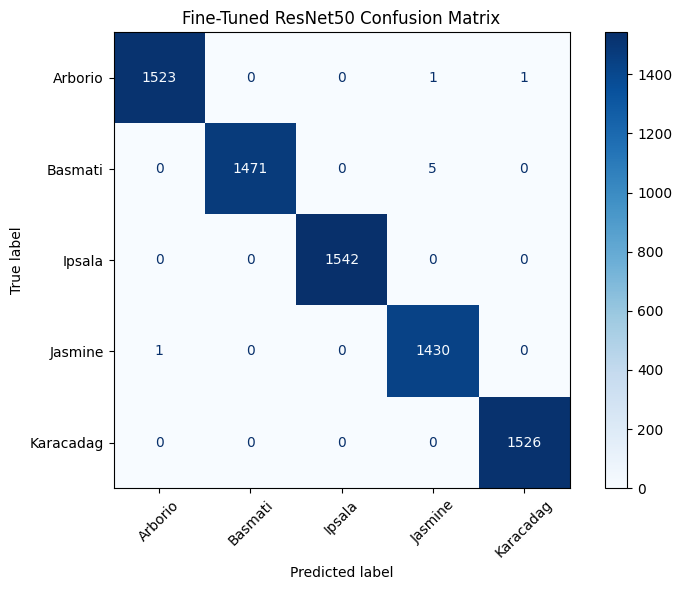

In [ ]:
# Plot the confusion matrix for the fine-tuned ResNet50 model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

finetune_cm = confusion_matrix(
    finetune_y_true,
    finetune_y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=finetune_cm,
    display_labels=rice_classes
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("Fine-Tuned ResNet50 Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Save the complete fine-tuned ResNet50 results
import json

finetune_results = {
    "best_epoch": int(best_finetune_epoch),
    "best_val_accuracy": float(best_finetune_val_accuracy),
    "best_val_loss": float(best_finetune_val_loss),
    "test_loss": float(finetune_test_loss),
    "test_accuracy": float(finetune_test_accuracy),
    "correct_predictions": int(finetune_correct_predictions),
    "incorrect_predictions": int(finetune_incorrect_predictions),
    "total_test_images": int(len(finetune_y_true)),
    "confusion_matrix": finetune_cm.tolist()
}

with open(
    "/content/drive/MyDrive/ResNet50_FineTune_Results_Final.json",
    "w"
) as file:
    json.dump(finetune_results, file, indent=4)

print("Fine-tuned ResNet50 results saved successfully.")

Fine-tuned ResNet50 results saved successfully.


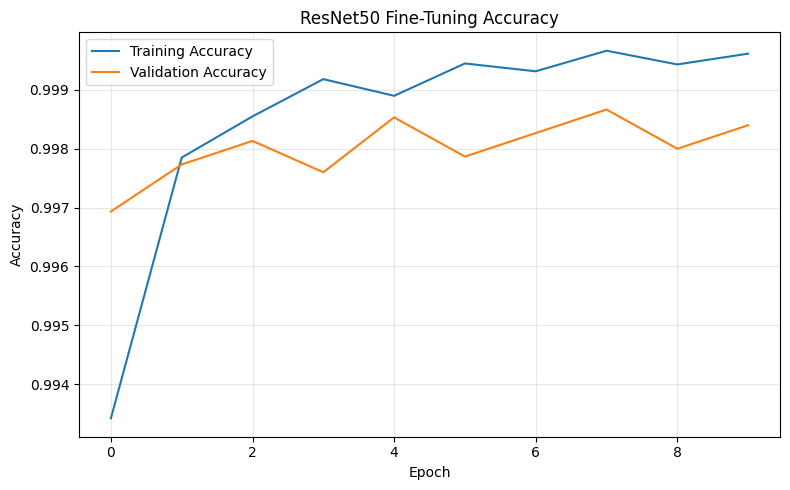

In [ ]:
# Plot training and validation accuracy for ResNet50 fine-tuning
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    finetune_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    finetune_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Fine-Tuning Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

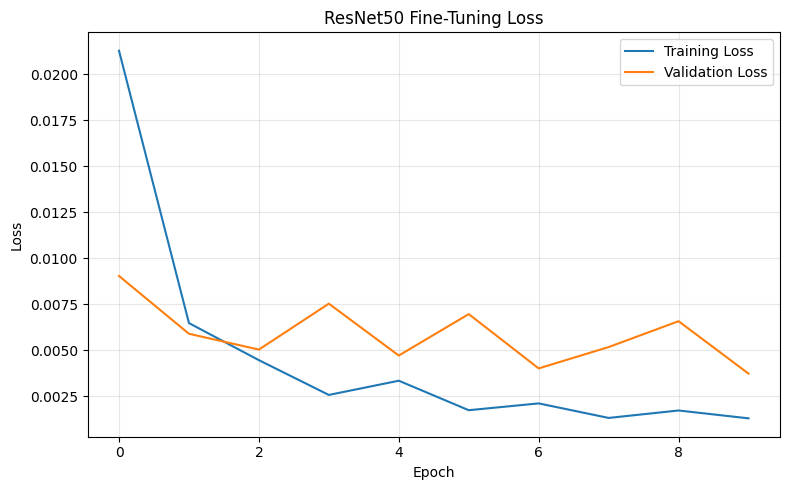

In [ ]:
# Plot training and validation loss for ResNet50 fine-tuning
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    finetune_history["loss"],
    label="Training Loss"
)

plt.plot(
    finetune_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Fine-Tuning Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Collect misclassified images from the fine-tuned ResNet50 model
finetune_misclassified_images = []
finetune_misclassified_true = []
finetune_misclassified_pred = []

for images, labels in resnet_test_dataset:
    predictions = resnet_finetune_best(images, training=False)
    predicted_labels = np.argmax(predictions.numpy(), axis=1)
    true_labels = labels.numpy()

    wrong_indices = np.where(predicted_labels != true_labels)[0]

    for i in wrong_indices:
        finetune_misclassified_images.append(images[i].numpy())
        finetune_misclassified_true.append(true_labels[i])
        finetune_misclassified_pred.append(predicted_labels[i])

print(
    "Total misclassified images:",
    len(finetune_misclassified_images)
)

Total misclassified images: 8


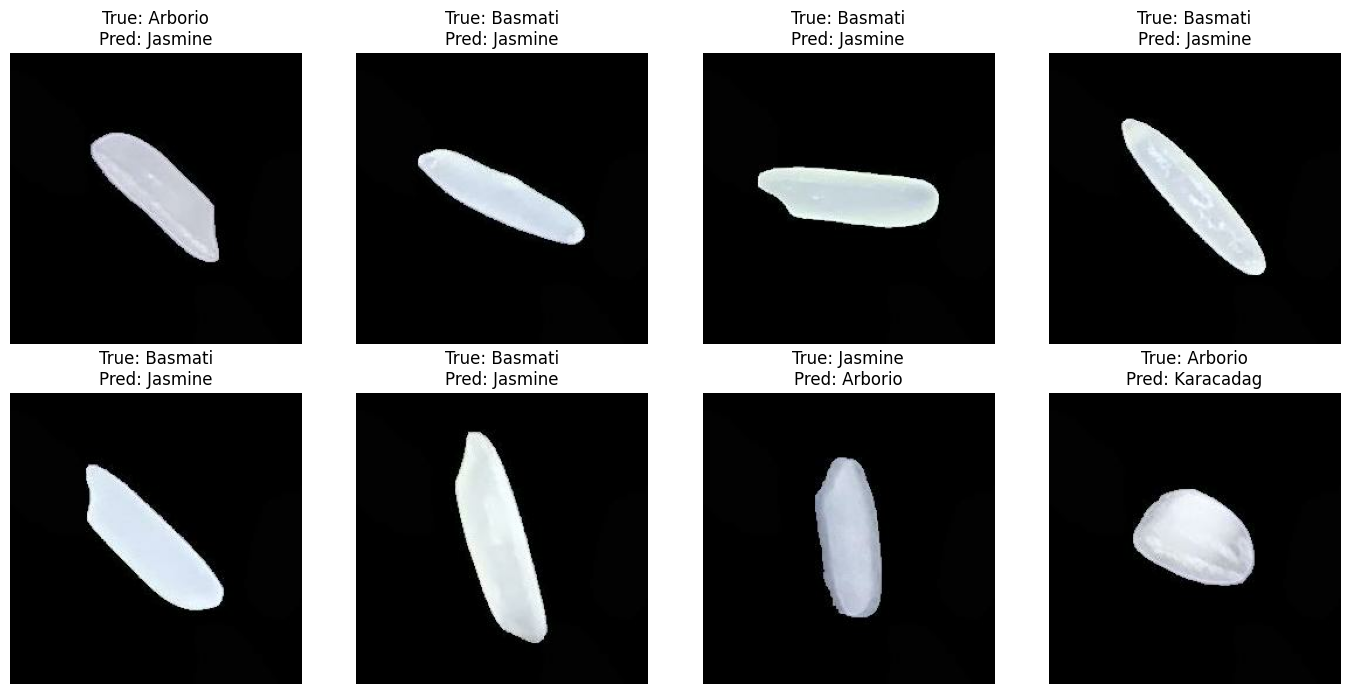

In [ ]:
# Display all misclassified images from the fine-tuned ResNet50 model
plt.figure(figsize=(14, 7))

for i in range(len(finetune_misclassified_images)):
    plt.subplot(2, 4, i + 1)

    image = finetune_misclassified_images[i]

    # Convert ResNet50-preprocessed image back for visualization
    image = image.copy()
    image[..., 0] += 103.939
    image[..., 1] += 116.779
    image[..., 2] += 123.68
    image = image[..., ::-1]
    image = np.clip(image / 255.0, 0, 1)

    plt.imshow(image)
    plt.title(
        f"True: {rice_classes[finetune_misclassified_true[i]]}\n"
        f"Pred: {rice_classes[finetune_misclassified_pred[i]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Load the best fine-tuned ResNet50 model

resnet_finetune_best = tf.keras.models.load_model(
    "/content/drive/MyDrive/ResNet50_FineTune_Epoch_08.keras"
)

print("Best fine-tuned ResNet50 model loaded successfully.")

Best fine-tuned ResNet50 model loaded successfully.


In [ ]:
# Load the best Improve2 CNN model (Epoch 31)
improve2_best = tf.keras.models.load_model(
    "/content/drive/MyDrive/Improve2_Epoch_31.keras"
)

print("Best Improve2 model loaded successfully.")

Best Improve2 model loaded successfully.


In [ ]:
# Find the test indices of the fine-tuned ResNet50 errors
finetune_error_indices = np.where(
    finetune_y_true != finetune_y_pred
)[0]

print("Fine-tuning error indices:")
print(finetune_error_indices)

print("Total errors:", len(finetune_error_indices))

Fine-tuning error indices:
[ 103  409  796 5037 5362 6547 6795 7364]
Total errors: 8


In [ ]:
# Collect the original test images corresponding to fine-tuning errors

error_images_by_index = {}
target_indices = set(finetune_error_indices.tolist())

current_index = 0

for images, labels in test_dataset:
    for image, label in zip(images, labels):
        if current_index in target_indices:
            error_images_by_index[current_index] = (
                image.numpy(),
                int(label.numpy())
            )
        current_index += 1

original_error_images = [
    error_images_by_index[i][0]
    for i in finetune_error_indices
]

original_error_labels = [
    error_images_by_index[i][1]
    for i in finetune_error_indices
]

print("Collected original error images:", len(original_error_images))

Collected original error images: 8


In [ ]:
# Compare fine-tuned ResNet50 errors with Improve2

for i, (image, true_label) in enumerate(
    zip(original_error_images, original_error_labels)
):
    image_batch = np.expand_dims(image, axis=0)

    prediction = improve2_best(image_batch, training=False)
    improve2_pred = np.argmax(prediction.numpy(), axis=1)[0]

    finetune_pred = finetune_y_pred[finetune_error_indices[i]]

    print(
        f"Image {i + 1} | "
        f"True: {rice_classes[true_label]} | "
        f"Fine-Tuned: {rice_classes[finetune_pred]} | "
        f"Improve2: {rice_classes[improve2_pred]}"
    )

Image 1 | True: Arborio | Fine-Tuned: Jasmine | Improve2: Jasmine
Image 2 | True: Basmati | Fine-Tuned: Jasmine | Improve2: Basmati
Image 3 | True: Basmati | Fine-Tuned: Jasmine | Improve2: Basmati
Image 4 | True: Basmati | Fine-Tuned: Jasmine | Improve2: Basmati
Image 5 | True: Basmati | Fine-Tuned: Jasmine | Improve2: Basmati
Image 6 | True: Basmati | Fine-Tuned: Jasmine | Improve2: Basmati
Image 7 | True: Jasmine | Fine-Tuned: Arborio | Improve2: Arborio
Image 8 | True: Arborio | Fine-Tuned: Karacadag | Improve2: Arborio


In [ ]:
# Generate Improve2 predictions on the test dataset

improve2_y_true = []
improve2_y_pred = []

for images, labels in test_dataset:
    predictions = improve2_best(images, training=False)
    predicted_labels = np.argmax(predictions.numpy(), axis=1)

    improve2_y_true.extend(labels.numpy())
    improve2_y_pred.extend(predicted_labels)

improve2_y_true = np.array(improve2_y_true)
improve2_y_pred = np.array(improve2_y_pred)

improve2_error_indices = np.where(
    improve2_y_true != improve2_y_pred
)[0]

print("Improve2 error indices:")
print(improve2_error_indices)
print("Total errors:", len(improve2_error_indices))

Improve2 error indices:
[   9  103 1078 1149 2803 3777 4031 4359 4515 4675 4962 5567 5632 5976
 6795]
Total errors: 15


In [ ]:
# Compare Improve2 errors with Fine-Tuned ResNet50

fixed_by_finetune = 0

for index in improve2_error_indices:

    true_label = improve2_y_true[index]
    improve2_pred = improve2_y_pred[index]
    finetune_pred = finetune_y_pred[index]

    if finetune_pred == true_label:
        fixed_by_finetune += 1

    print(
        f"Test Index {index} | "
        f"True: {rice_classes[true_label]} | "
        f"Improve2: {rice_classes[improve2_pred]} | "
        f"Fine-Tuned: {rice_classes[finetune_pred]}"
    )

print("\nImprove2 errors fixed by Fine-Tuning:", fixed_by_finetune)

Test Index 9 | True: Arborio | Improve2: Jasmine | Fine-Tuned: Arborio
Test Index 103 | True: Arborio | Improve2: Jasmine | Fine-Tuned: Jasmine
Test Index 1078 | True: Arborio | Improve2: Karacadag | Fine-Tuned: Arborio
Test Index 1149 | True: Karacadag | Improve2: Arborio | Fine-Tuned: Karacadag
Test Index 2803 | True: Arborio | Improve2: Karacadag | Fine-Tuned: Arborio
Test Index 3777 | True: Jasmine | Improve2: Basmati | Fine-Tuned: Jasmine
Test Index 4031 | True: Karacadag | Improve2: Arborio | Fine-Tuned: Karacadag
Test Index 4359 | True: Ipsala | Improve2: Arborio | Fine-Tuned: Ipsala
Test Index 4515 | True: Jasmine | Improve2: Basmati | Fine-Tuned: Jasmine
Test Index 4675 | True: Jasmine | Improve2: Basmati | Fine-Tuned: Jasmine
Test Index 4962 | True: Jasmine | Improve2: Arborio | Fine-Tuned: Jasmine
Test Index 5567 | True: Arborio | Improve2: Jasmine | Fine-Tuned: Arborio
Test Index 5632 | True: Arborio | Improve2: Karacadag | Fine-Tuned: Arborio
Test Index 5976 | True: Karaca

Improve2 vs. Fine-Tuned ResNet50 Comparison
The Improve2 model produced 15 errors on the test set. Fine-Tuned ResNet50 corrected 13 of these 15 errors, while 2 errors remained common to both models. However, Fine-Tuned ResNet50 introduced 6 new errors on images that Improve2 had classified correctly.
As a result, the total number of errors decreased from 15 to 8, while test accuracy improved from 99.80% to 99.89%.
Conclusion: Fine-tuning improved the overall classification performance, although it introduced a small number of new errors while correcting most of the errors made by Improve2.

In [ ]:
# Load saved results for all models

import json

result_files = {
    "Baseline": "/content/drive/MyDrive/Baseline_Results_Final.json",
    "Improved": "/content/drive/MyDrive/Improved_Results_Final.json",
    "Augmented": "/content/drive/MyDrive/Augmented_Results_Final.json",
    "Improve2": "/content/drive/MyDrive/Improve2_Results_Final.json",
    "ResNet50": "/content/drive/MyDrive/ResNet50_Results_Final.json",
    "Fine-Tuned ResNet50": "/content/drive/MyDrive/ResNet50_FineTune_Results_Final.json"
}

all_results = {}

for model_name, file_path in result_files.items():
    with open(file_path, "r") as file:
        all_results[model_name] = json.load(file)

for model_name, results in all_results.items():
    print(model_name, results["test_accuracy"])

Baseline 0.9857333302497864
Improved 0.9918666481971741
Augmented 0.9911999702453613
Improve2 0.9980000257492065
ResNet50 0.996399998664856
Fine-Tuned ResNet50 0.9989333152770996


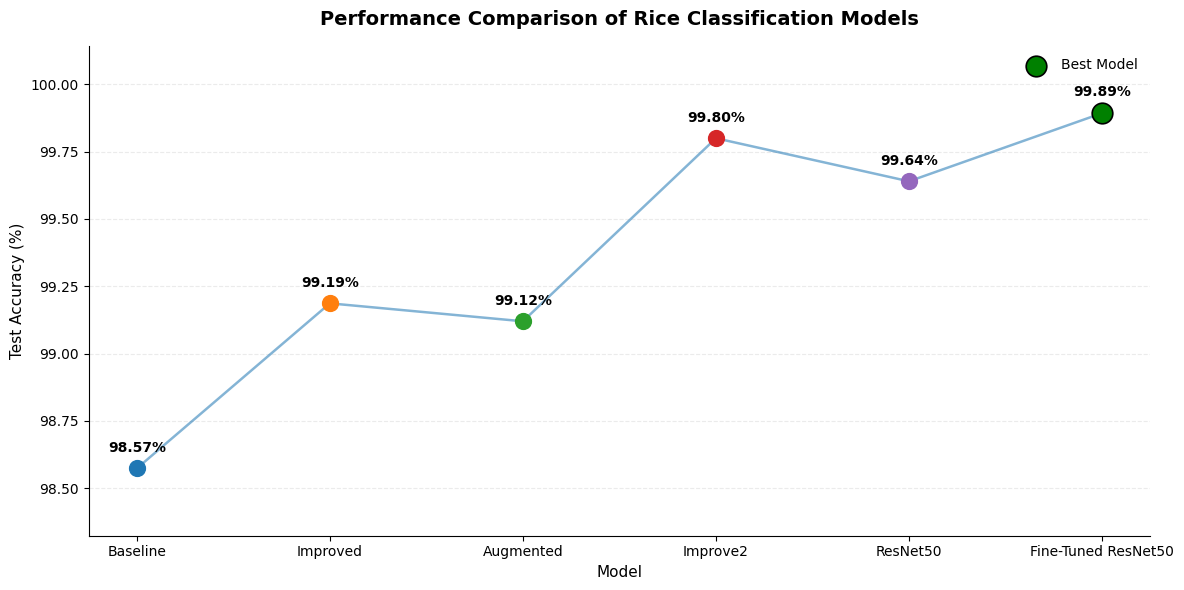

In [ ]:
# Create a professional comparison plot from saved model results

model_names = list(all_results.keys())
test_accuracies = np.array([
    all_results[name]["test_accuracy"] * 100
    for name in model_names
])

best_index = np.argmax(test_accuracies)

fig, ax = plt.subplots(figsize=(12, 6))

# Connect model performances
ax.plot(
    range(len(model_names)),
    test_accuracies,
    linewidth=1.8,
    alpha=0.55
)

# Plot all models
for i, accuracy in enumerate(test_accuracies):

    if i == best_index:
        ax.scatter(
            i, accuracy,
            s=220,
            color="green",
            edgecolor="black",
            linewidth=1.2,
            zorder=3,
            label="Best Model"
        )
    else:
        ax.scatter(
            i, accuracy,
            s=130,
            zorder=3
        )

    ax.annotate(
        f"{accuracy:.2f}%",
        (i, accuracy),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, fontsize=10)

ax.set_ylabel("Test Accuracy (%)", fontsize=11)
ax.set_xlabel("Model", fontsize=11)

ax.set_title(
    "Performance Comparison of Rice Classification Models",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_ylim(
    min(test_accuracies) - 0.25,
    max(test_accuracies) + 0.25
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## Final Model Sample Predictions

To visually examine the performance of the final Fine-Tuned ResNet50 model, one test sample from each rice class is shown below together with its predicted class and confidence score.

In [18]:
# Check available samples

print("Rice classes:", rice_classes)
print("Collected samples:", sample_images.keys())
print("Number of samples:", len(sample_images))

Rice classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Collected samples: dict_keys([3, 2, 1, 4, 0])
Number of samples: 5


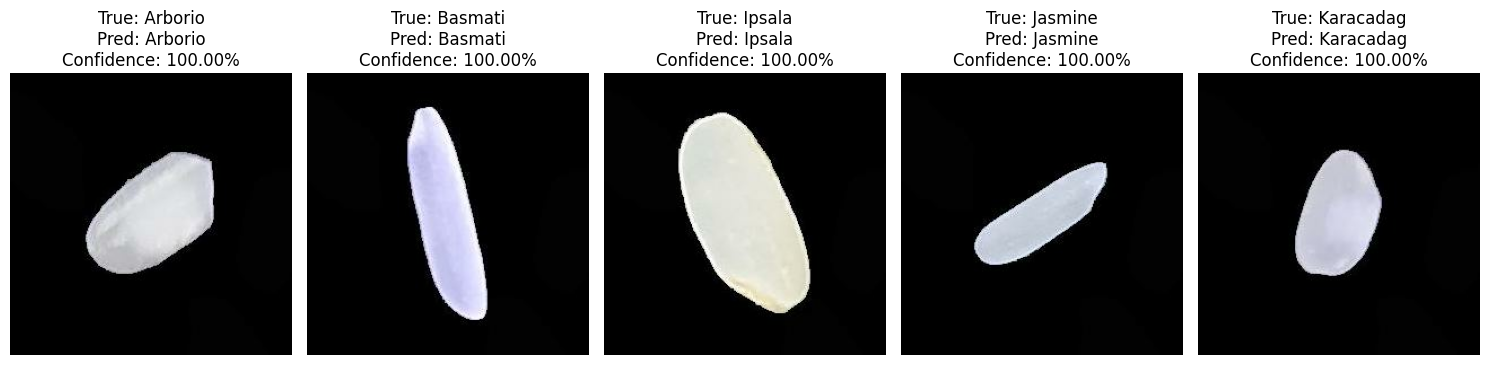

In [21]:
# Display predictions for one sample from each rice class

plt.figure(figsize=(15, 4))

for i in range(len(rice_classes)):

    image = sample_images[i]

    input_image = tf.expand_dims(image * 255.0, axis=0)
    input_image = tf.keras.applications.resnet50.preprocess_input(input_image)

    prediction = resnet_finetune_best(input_image, training=False)

    predicted_label = np.argmax(prediction.numpy(), axis=1)[0]
    confidence = np.max(prediction.numpy()) * 100

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"True: {rice_classes[i]}\n"
        f"Pred: {rice_classes[predicted_label]}\n"
        f"Confidence: {confidence:.2f}%"
    )

plt.tight_layout()
plt.show()

# Final Conclusion
In this project, several deep learning approaches were developed and evaluated for the classification of five rice varieties: Arborio, Basmati, Ipsala, Jasmine, and Karacadag.

The experiments started with a baseline CNN and were progressively improved by modifying the network architecture, introducing Global Average Pooling and Dropout, applying data augmentation, increasing the feature extraction capacity of the CNN, and finally using transfer learning and fine-tuning with ResNet50.

The final test performances were:

Baseline CNN: 98.57% accuracy — 107 misclassified images
Improved CNN: 99.19% accuracy — 61 misclassified images
Augmented CNN: 99.12% accuracy — 66 misclassified images
Improve2 CNN: 99.80% accuracy — 15 misclassified images
ResNet50 Transfer Learning: 99.64% accuracy — 27 misclassified images
Fine-Tuned ResNet50: 99.89% accuracy — 8 misclassified images
The results show that architectural improvements substantially increased classification performance while reducing the number of errors. Data augmentation did not improve test accuracy in this experiment, while the deeper Improve2 architecture achieved very strong performance with only 15 errors.

Transfer learning with ResNet50 also achieved high classification accuracy. Fine-tuning selected deeper layers of the pretrained network further improved its ability to adapt to the rice dataset and produced the best overall result.

A detailed error comparison between Improve2 and Fine-Tuned ResNet50 showed that Fine-Tuned ResNet50 corrected 13 of the 15 errors made by Improve2. Two errors remained common to both models, while Fine-Tuned ResNet50 introduced six new errors on images that Improve2 had classified correctly. Despite these new errors, the total number of misclassifications decreased from 15 to 8.

Overall, Fine-Tuned ResNet50 achieved the best performance with 99.89% test accuracy and only 8 misclassified images out of 7,500 test samples.

Therefore, Fine-Tuned ResNet50 was selected as the best-performing model in this study.